# Fraud Detector — EDA & Trend Analysis

**Purpose:** Surface fraud trends, category distributions, signal patterns, and source intelligence from the multi-source corpus.

**Sources:** FinCEN · FTC · FBI · IC3 · BleepingComputer · Outseer

**Output:** Aggregated tables and charts — each section maps directly to a future dashboard panel.

---
| Section | Dashboard Panel |
|---|---|
| 4 — Category Distribution | Top fraud types bar chart |
| 5 — Trend Over Time | Fraud category line chart by year |
| 6 — Source Comparison | Source vs. category heatmap |
| 7 — Signal Analysis | Signal frequency scorecards |
| 8 — Signal Co-occurrence | Compound fraud pattern heatmap |
| 9 — Emerging Threats | Rising/falling category indicators |
| 10 — Export | Dashboard-ready CSVs |

## Step 0 — Install Dependencies

In [1]:
!pip install -q pandas numpy matplotlib seaborn

## Step 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── UPDATE this path to match your actual Drive folder ──
DRIVE_FOLDER = os.path.join(
    os.environ.get('FRAUD_BASE_DIR',
        '/content/drive/MyDrive/6390 UNCC Practicum - USAA/Fraud_model.v4'),
    'outputs'
)

print('Files found in output folder:')
if os.path.exists(DRIVE_FOLDER):
    for f in sorted(os.listdir(DRIVE_FOLDER)):
        print(' ', f)
else:
    print('  Folder not found — check DRIVE_FOLDER path')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found in output folder:
  OLD
  bleepingcomputer_fraud_data.csv
  bleepingcomputer_fraud_data.jsonl
  bleepingcomputer_raw.jsonl
  dashboard_exports
  fbi_master.csv
  fbi_master.jsonl
  fbi_tagged_chunks.jsonl
  fincen_tagged_chunks.jsonl
  ftc_master.csv
  ftc_master.jsonl
  ic3_master.csv
  ic3_master.jsonl
  ic3_tagged_chunks.jsonl
  outseer_scraped_data.csv
  outseer_scraped_data.json
  outseer_scraped_data.jsonl
  pymnts_master.csv
  pymnts_master.jsonl


## Step 2 — Load All Data Sources

In [3]:
# ── Helper functions (defined here so they're available for all sources below) ──
def ensure_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            parsed = json.loads(val)
            return parsed if isinstance(parsed, list) else [parsed]
        except:
            return [val] if val.strip() else []
    return []

def parse_signals(sig):
    if isinstance(sig, dict):
        return sig
    if isinstance(sig, str):
        try:
            return json.loads(sig)
        except:
            return {}
    return {}

def coerce_date(val):
    """
    Robustly parse a date value into a pandas Timestamp.
    Handles: ISO strings, epoch milliseconds (int/float), NaT, NaN, empty string.
    """
    if pd.isna(val) or val == '' or val is None:
        return pd.NaT
    # Epoch milliseconds — pd.read_json() converts date strings to ms integers
    if isinstance(val, (int, float)):
        if val > 1e10:          # milliseconds (13-digit)
            return pd.Timestamp(val, unit='ms', tz='UTC')
        elif val > 1e7:         # seconds (10-digit)
            return pd.Timestamp(val, unit='s', tz='UTC')
        return pd.NaT
    # String — try ISO parse
    try:
        return pd.to_datetime(str(val), utc=True, errors='coerce')
    except Exception:
        return pd.NaT

import pandas as pd
import json
import numpy as np

def load_jsonl(path, source_name):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    df = pd.DataFrame(records)
    df['source'] = source_name
    print(f'  [{source_name}] {len(df)} rows loaded')
    return df

dfs = []

# ── FinCEN
p = os.path.join(DRIVE_FOLDER, 'fincen_tagged_chunks.jsonl')
if os.path.exists(p):
    df = load_jsonl(p, 'FinCEN')
    df['text'] = df['body_1'] if 'body_1' in df.columns else ''
    df['date'] = df['date'] if 'date' in df.columns else pd.NaT
    dfs.append(df)
else:
    print('  [SKIP] fincen_tagged_chunks.jsonl not found')

# ── FTC
p = os.path.join(DRIVE_FOLDER, 'ftc_master.jsonl')
if os.path.exists(p):
    df = load_jsonl(p, 'FTC')
    df['text'] = df['body_1'] if 'body_1' in df.columns else df.get('body', df.get('body_short', ''))
    df['date'] = df['date'] if 'date' in df.columns else pd.NaT
    dfs.append(df)
else:
    print('  [SKIP] ftc_master.jsonl not found')

# ── FBI
p = os.path.join(DRIVE_FOLDER, 'fbi_tagged_chunks.jsonl')
if os.path.exists(p):
    df = load_jsonl(p, 'FBI')
    df['text'] = df['body_1'] if 'body_1' in df.columns else ''
    df['date'] = df['date'] if 'date' in df.columns else pd.NaT
    dfs.append(df)
else:
    print('  [SKIP] fbi_tagged_chunks.jsonl not found')

# ── IC3
p = os.path.join(DRIVE_FOLDER, 'ic3_tagged_chunks.jsonl')
if os.path.exists(p):
    df = load_jsonl(p, 'IC3')
    df['text'] = df['body_1'] if 'body_1' in df.columns else ''
    df['date'] = df['date'] if 'date' in df.columns else pd.NaT
    dfs.append(df)
else:
    print('  [SKIP] ic3_tagged_chunks.jsonl not found')

# ── BleepingComputer
p = os.path.join(DRIVE_FOLDER, 'bleepingcomputer_fraud_data.csv')
if os.path.exists(p):
    df = pd.read_csv(p)
    df['source'] = 'BleepingComputer'
    df['text'] = df['body_1'] if 'body_1' in df.columns else df.get('content', '')
    df['fraud_tags'] = df['fraud_tags'].apply(ensure_list) if 'fraud_tags' in df.columns else (
        df['fraud_type'].apply(lambda x: [x] if pd.notna(x) else []) if 'fraud_type' in df.columns
        else [[] for _ in range(len(df))])
    df['fraud_signals'] = [{}] * len(df)
    # Normalise date field name
    print(f'  [BleepingComputer] {len(df)} rows loaded')
    dfs.append(df)
else:
    print('  [SKIP] bleepingcomputer_fraud_data.csv not found')

# ── Outseer
# FIX v5: pd.read_json() converts ISO date strings to epoch milliseconds.
# Use coerce_date() to convert them back correctly.
p = os.path.join(DRIVE_FOLDER, 'outseer_scraped_data.json')
if os.path.exists(p):
    df = pd.read_json(p)
    df['source'] = 'Outseer'
    df['text'] = df['body_1'] if 'body_1' in df.columns else df.get('content', '')
    df['fraud_tags']    = df['fraud_tags'].apply(ensure_list)    if 'fraud_tags'    in df.columns else [[] for _ in range(len(df))]
    df['fraud_signals'] = df['fraud_signals'].apply(parse_signals) if 'fraud_signals' in df.columns else [{}] * len(df)
    # Prefer the 'date' column; fall back to 'published' or 'published_raw'
    date_col = next((c for c in ['date', 'published', 'published_raw'] if c in df.columns), None)
    df['date'] = df[date_col].apply(coerce_date) if date_col else pd.NaT
    print(f'  [Outseer] {len(df)} rows loaded — dates resolved: {df["date"].notna().sum()}')
    dfs.append(df)
else:
    print('  [SKIP] outseer_scraped_data.json not found')

# ── PYMNTS
p = os.path.join(DRIVE_FOLDER, 'pymnts_master.jsonl')
if os.path.exists(p):
    df = load_jsonl(p, 'PYMNTS')
    df['text'] = df['body_1'] if 'body_1' in df.columns else df.get('body', df.get('body_short', ''))
    df['date'] = df['date'] if 'date' in df.columns else pd.NaT
    dfs.append(df)
else:
    print('  [SKIP] pymnts_master.jsonl not found')

print(f'\nTotal sources loaded: {len(dfs)}')


  [FinCEN] 40 rows loaded
  [FTC] 200 rows loaded
  [FBI] 137 rows loaded
  [IC3] 6 rows loaded
  [BleepingComputer] 550 rows loaded
  [Outseer] 19 rows loaded — dates resolved: 13
  [PYMNTS] 285 rows loaded

Total sources loaded: 7


## Step 3 — Build Master DataFrame

In [4]:
# (ensure_list and parse_signals defined in Step 2 above)

normalized = []
for df in dfs:
    sub = pd.DataFrame()
    sub['text']          = df['text'].astype(str) if 'text' in df.columns else ''
    sub['fraud_tags']    = df['fraud_tags'].apply(ensure_list) if 'fraud_tags' in df.columns else [[] for _ in range(len(df))]
    sub['fraud_signals'] = df['fraud_signals'].apply(parse_signals) if 'fraud_signals' in df.columns else [{} for _ in range(len(df))]
    # v5: use coerce_date to handle ISO strings, epoch ms ints, and missing values
    raw_date = df['date'] if 'date' in df.columns else pd.NaT
    sub['date'] = raw_date.apply(coerce_date) if hasattr(raw_date, 'apply') else coerce_date(raw_date)
    sub['source']        = df['source']
    # Carry doc_id through — required for body_N join and groupby dedup
    sub['doc_id']        = df['doc_id'].values if 'doc_id' in df.columns else None
    normalized.append(sub)

master = pd.concat(normalized, ignore_index=True)

# ── Attach body_N columns from wide-format sources (FinCEN, FBI, IC3) ────────
# The normalization loop above strips down to 5 cols for EDA consistency.
# We re-join body_1..N from the original dfs so save_master can write them
# to master_flat_docs.csv. Non-chunked sources only have body_1; chunked
# sources may have body_2, body_3, etc. Columns are unioned across all sources
# (sparse is fine — non-chunked rows will have NaN for body_2+).
_body_frames = []
for _df in dfs:
    _body_cols = sorted(
        [c for c in _df.columns if c.startswith('body_') and c.split('_')[1].isdigit()],
        key=lambda c: int(c.split('_')[1])
    )
    if _body_cols and 'doc_id' in _df.columns:
        _body_frames.append(_df[['doc_id'] + _body_cols].copy())

if _body_frames:
    import functools
    _body_wide = functools.reduce(
        lambda a, b: pd.merge(a, b, on='doc_id', how='outer', suffixes=('', '_dup')),
        _body_frames
    )
    # Drop any duplicate columns created by merge
    _body_wide = _body_wide[[c for c in _body_wide.columns if not c.endswith('_dup')]]
    # Ensure doc_id exists on master before merging
    if 'doc_id' not in master.columns:
        master['doc_id'] = master.index.astype(str)
    master = master.merge(_body_wide, on='doc_id', how='left')
    _new_body_cols = [c for c in master.columns if c.startswith('body_') and c.split('_')[1].isdigit()]
    print(f'  body_N columns attached: {_new_body_cols}')

# ── v6 fix: re-cast date column after concat — mixed types across sources
# can silently downgrade the column to object dtype, breaking .dt accessors
master['date'] = pd.to_datetime(master['date'], utc=True, errors='coerce')

# Drop rows with no meaningful text
master = master[master['text'].str.strip().str.len() > 20].reset_index(drop=True)

# Time dimensions
master['year']  = master['date'].dt.year
master['month'] = master['date'].dt.month
master['quarter'] = master['date'].dt.to_period('Q').astype(str)

# Signal features
# Signal parsing — handles dict (FTC/FBI/IC3), flat list (FinCEN), and empty ({})
def safe_has(sig, *keys):
    if isinstance(sig, dict):
        for k in keys:
            if len(sig.get(k, [])) > 0:
                return True
    elif isinstance(sig, list):
        # FinCEN stores signals as flat keyword list — check for signal category keywords
        joined = ' '.join(sig).lower()
        for k in keys:
            if k in joined:
                return True
    return False

master['has_url']      = master['fraud_signals'].apply(lambda x: safe_has(x, 'urls', 'url'))
master['has_email']    = master['fraud_signals'].apply(lambda x: safe_has(x, 'emails', 'email', 'email address'))
master['has_phone']    = master['fraud_signals'].apply(lambda x: safe_has(x, 'phones', 'phone', 'phone number'))
master['has_ip']       = master['fraud_signals'].apply(lambda x: safe_has(x, 'ips', 'ip_addresses', 'ip'))
master['has_crypto']   = master['fraud_signals'].apply(lambda x: safe_has(x, 'crypto', 'btc', 'crypto_wallets', 'crypto_signal', 'cryptocurrency'))
master['signal_count'] = master['fraud_signals'].apply(
    lambda x: sum(len(v) for v in x.values() if isinstance(v, list)) if isinstance(x, dict)
    else len(x) if isinstance(x, list) else 0
)
master['text_length']  = master['text'].str.len()
master['tag_count']    = master['fraud_tags'].apply(len)

# ── Normalize fraud_tags to flat list of strings ──────────────────────────────
# Must happen before any groupby/explode — nested lists cause unhashable errors.
# Handles: ["cybercrime"], [["cybercrime"]], ["[\'cybercrime\']"], mixed nesting.
import ast

def normalize_fraud_tags(val):
    """Guarantee fraud_tags is always a flat list of clean strings."""
    # Already a flat list of strings — most common case
    if isinstance(val, list):
        flat = []
        for t in val:
            if isinstance(t, list):
                flat.extend(str(x).strip() for x in t if x and str(x).strip())
            elif isinstance(t, str):
                t = t.strip()
                if t:
                    # May still be a JSON/Python stringified list e.g. "[\'cybercrime\']"
                    if t.startswith('['):
                        try:
                            parsed = json.loads(t)
                            flat.extend(str(x).strip() for x in parsed if x)
                            continue
                        except Exception:
                            pass
                        try:
                            parsed = ast.literal_eval(t)
                            flat.extend(str(x).strip() for x in parsed if x)
                            continue
                        except Exception:
                            pass
                    flat.append(t)
        return flat if flat else ['other']
    elif isinstance(val, str):
        val = val.strip()
        if not val:
            return ['other']
        if val.startswith('['):
            try:
                parsed = json.loads(val)
                return [str(x).strip() for x in parsed if x] or ['other']
            except Exception:
                pass
            try:
                parsed = ast.literal_eval(val)
                return [str(x).strip() for x in parsed if x] or ['other']
            except Exception:
                pass
        return [val] if val else ['other']
    return ['other']

master['fraud_tags'] = master['fraud_tags'].apply(normalize_fraud_tags)

print('Master dataset shape:', master.shape)
print('Date range:', master['date'].min(), '→', master['date'].max())
print('\nSource counts:')
print(master['source'].value_counts().to_string())
print('\nRecords with at least one fraud tag:', (master['tag_count'] > 0).sum())

  body_N columns attached: ['body_1', 'body_2', 'body_3', 'body_4', 'body_5', 'body_6', 'body_7', 'body_8', 'body_9', 'body_10', 'body_11', 'body_12', 'body_13', 'body_14', 'body_15', 'body_16', 'body_17', 'body_18', 'body_19', 'body_20', 'body_21', 'body_22', 'body_23', 'body_24', 'body_25', 'body_26', 'body_27', 'body_28', 'body_29', 'body_30', 'body_31', 'body_32', 'body_33', 'body_34', 'body_35', 'body_36', 'body_37', 'body_38', 'body_39', 'body_40', 'body_41', 'body_42', 'body_43', 'body_44', 'body_45', 'body_46', 'body_47', 'body_48', 'body_49', 'body_50', 'body_51', 'body_52', 'body_53', 'body_54', 'body_55', 'body_56', 'body_57', 'body_58', 'body_59', 'body_60']
Master dataset shape: (1237, 77)
Date range: 2018-05-09 00:00:00+00:00 → 2026-04-18 00:00:00+00:00

Source counts:
source
BleepingComputer    550
PYMNTS              285
FTC                 200
FBI                 137
FinCEN               40
Outseer              19
IC3                   6

Records with at least one frau

/tmp/ipykernel_67213/4224785235.py:59: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  master['quarter'] = master['date'].dt.to_period('Q').astype(str)


In [5]:
# ══════════════════════════════════════════════════════════════
# Cell 4b — Build analysis views
#
# Option 1 — master_docs   : one row per document (union-merged tags)
#   Best for: category counts, source comparison, trend analysis
#   Unit of analysis: documents — every source gets equal weight
#
# Option 2 — master_weighted: chunk rows with weight = 1/chunks_per_doc
#   Best for: preserving granularity while correcting for chunk inflation
#   Unit of analysis: weighted chunks — long docs don't dominate counts
#
# master (raw chunks, kept for RAG / downstream search use)
# ══════════════════════════════════════════════════════════════

# ── Sources that chunk long documents ────────────────────────
CHUNKED_SOURCES = {'FinCEN', 'FBI', 'IC3'}

# ── Assign doc_id where missing (non-chunked sources) ────────
# Non-chunked sources don't have a doc_id column — use index as proxy
if 'doc_id' not in master.columns:
    master['doc_id'] = master.index.astype(str)

# For non-chunked sources, each row IS the document — assign unique doc_id
mask_no_id = master['doc_id'].isna() | (master['doc_id'] == '')
master.loc[mask_no_id, 'doc_id'] = [
    f'doc_{i}' for i in master[mask_no_id].index
]

# ── Option 2: chunk weight = 1 / number of chunks per doc_id ─
chunk_counts      = master.groupby('doc_id')['doc_id'].transform('count')
master['chunk_weight'] = 1.0 / chunk_counts

# ── Temporarily serialize list columns before groupby ─────────
# pandas groupby/factorize cannot handle list-valued columns.
# We serialize fraud_tags → JSON string, groupby, then parse back.
master['_fraud_tags_str'] = master['fraud_tags'].apply(json.dumps)

# ── Option 1: collapse to doc-level via union merge ───────────
def union_tags(series):
    seen, merged = set(), []
    for tags in series:
        # Normalize: ensure we always have a flat list of strings
        if not isinstance(tags, list):
            tags = [tags] if tags else []
        for t in tags:
            # Flatten nested lists e.g. [["cybercrime"]] from CSV round-trip
            if isinstance(t, list):
                inner = t
            else:
                inner = [t]
            for item in inner:
                item = str(item).strip() if item else ''
                if item and item not in seen:
                    merged.append(item)
                    seen.add(item)
    return merged if merged else ['other']

def union_signals(series):
    merged = {}
    for sig in series:
        if isinstance(sig, dict):
            for k, v in sig.items():
                existing = merged.get(k, [])
                merged[k] = list(set(existing + (v if isinstance(v, list) else [])))
        elif isinstance(sig, list):
            merged.setdefault('keywords', [])
            merged['keywords'] = list(set(merged['keywords'] + sig))
    return merged

# Group only on scalar columns — list columns are excluded from groupby keys
_group_cols = ['doc_id', 'source', 'date', 'year', 'month', 'quarter']

# Aggregate scalar signal flags per doc
_scalar_agg = (
    master
    .groupby(_group_cols, as_index=False)
    .agg(
        text_length = ('text_length', 'sum'),
        has_url     = ('has_url',     'max'),
        has_email   = ('has_email',   'max'),
        has_phone   = ('has_phone',   'max'),
        has_ip      = ('has_ip',      'max'),
        has_crypto  = ('has_crypto',  'max'),
    )
)

# Aggregate list columns separately using apply (safe for list values)
_tags_agg = (
    master
    .groupby('doc_id')['fraud_tags']
    .apply(union_tags)
    .reset_index(name='fraud_tags')
)
# Guard: drop stray level_1 column if pandas expanded the tags list
_tags_agg = _tags_agg[[c for c in _tags_agg.columns if c != 'level_1']]

# Use drop_duplicates instead of groupby/apply to avoid pandas expanding
# dict-valued fraud_signals into multiple rows (a known pandas behaviour
# where apply() on a Series of dicts expands dict keys into a MultiIndex).
# Since each doc is already one row in master (wide-format pipeline output),
# taking the first row per doc_id gives the correct unioned signals value.
_signals_agg = (
    master
    .drop_duplicates(subset=['doc_id'], keep='first')[['doc_id', 'fraud_signals']]
    .copy()
    .reset_index(drop=True)
)

# Merge everything back together
master_docs = (
    _scalar_agg
    .merge(_tags_agg,    on='doc_id', how='left')
    .merge(_signals_agg, on='doc_id', how='left')
)

# Clean up temp column
master.drop(columns=['_fraud_tags_str'], inplace=True, errors='ignore')
master_docs['tag_count']    = master_docs['fraud_tags'].apply(len)
master_docs['signal_count'] = master_docs['fraud_signals'].apply(
    lambda x: sum(len(v) for v in x.values() if isinstance(v, list))
    if isinstance(x, dict) else len(x) if isinstance(x, list) else 0
)

# master_weighted is just master with chunk_weight already added above
master_weighted = master.copy()

print('=' * 55)
print('VIEW SUMMARY')
print('=' * 55)
print(f'master (raw chunks):     {len(master):,} rows')
print(f'master_docs (doc-level): {len(master_docs):,} rows  ← Option 1')
print(f'master_weighted (wtd):   {len(master_weighted):,} rows  ← Option 2')
print()
print('Doc-level source counts:')
print(master_docs['source'].value_counts().to_string())
print()
print('Chunk counts per source (chunked sources > 1 avg):')
avg_chunks = master.groupby('source')['chunk_weight'].apply(lambda x: round(1/x.mean(), 1))
print(avg_chunks.to_string())

# ── Primary tag (Option B: most keyword hits, tiebreak by severity) ──────────
#
# For each document, count how many keywords from each fraud family appear
# in the full text. The family with the most hits becomes primary_tag.
# Ties are broken by a fixed severity-ranked priority order.
#
# This is applied to all three master dataframes so every view has
# a consistent single-label field for executive summary charts.

# Severity-ranked tiebreak order (higher index = lower priority)
TAG_PRIORITY = [
    'terrorist_financing',
    'human_trafficking',
    'sanctions',
    'money_laundering',
    'crypto_fraud',
    'cybercrime',
    'identity_fraud',
    'consumer_fraud',
    'check_fraud',
    'benefits_fraud',
    'other',
]

# Build keyword → family lookup from the canonical fraud_dictionary
# fraud_dictionary is defined in Cell 3 (load sources) via FinCEN/FBI/IC3 pipelines
# We rebuild it here directly so this cell is self-contained
_FRAUD_DICT = [
    ("shell company", "money_laundering"), ("shell companies", "money_laundering"),
    ("shell corporation", "money_laundering"), ("front company", "money_laundering"),
    ("money mule", "money_laundering"), ("mule account", "money_laundering"),
    ("layering", "money_laundering"), ("structuring", "money_laundering"),
    ("smurfing", "money_laundering"), ("placement", "money_laundering"),
    ("beneficial owner", "money_laundering"),
    ("check fraud", "check_fraud"), ("mail theft", "check_fraud"),
    ("stolen check", "check_fraud"), ("stolen checks", "check_fraud"),
    ("check washing", "check_fraud"), ("fraudulent check", "check_fraud"),
    ("altered check", "check_fraud"), ("forged check", "check_fraud"),
    ("sanctions evasion", "sanctions"), ("sanctioned entity", "sanctions"),
    ("export control violation", "sanctions"),
    ("terrorist financing", "terrorist_financing"),
    ("terrorist organization", "terrorist_financing"),
    ("human trafficking", "human_trafficking"),
    ("labor trafficking", "human_trafficking"),
    ("romance scam", "consumer_fraud"), ("lottery scam", "consumer_fraud"),
    ("charity fraud", "consumer_fraud"), ("investment scam", "consumer_fraud"),
    ("scam", "consumer_fraud"), ("fraudster", "consumer_fraud"),
    ("gift card scam", "consumer_fraud"), ("imposter scam", "consumer_fraud"),
    ("identity theft", "identity_fraud"), ("stolen identity", "identity_fraud"),
    ("synthetic identity", "identity_fraud"), ("account takeover", "identity_fraud"),
    ("identity document", "identity_fraud"), ("credential theft", "identity_fraud"),
    ("government benefits fraud", "benefits_fraud"),
    ("medicaid fraud", "benefits_fraud"), ("pandemic relief fraud", "benefits_fraud"),
    ("ransomware", "cybercrime"), ("phishing", "cybercrime"),
    ("malware", "cybercrime"), ("data breach", "cybercrime"),
    ("credential stuffing", "cybercrime"), ("social engineering", "cybercrime"),
    ("virtual currency", "crypto_fraud"), ("cryptocurrency", "crypto_fraud"),
    ("crypto exchange", "crypto_fraud"), ("pig butchering", "crypto_fraud"),
    ("wallet", "crypto_fraud"), ("crypto wallet", "crypto_fraud"),
    ("rug pull", "crypto_fraud"),
]

def get_primary_tag(text, fraud_tags):
    """
    Determine primary_tag for a document using keyword hit counting.
    - Count occurrences of each fraud family's keywords in the text
    - Family with most hits wins
    - Ties broken by TAG_PRIORITY severity order
    - Falls back to first tag in fraud_tags if text is empty
    """
    # Normalize before any set() operation
    fraud_tags = normalize_fraud_tags(fraud_tags)

    if not fraud_tags or fraud_tags == ['other']:
        return 'other'

    text_lower = (text or '').lower()

    # Only score families that actually appear in this doc's fraud_tags
    candidate_families = set(fraud_tags) - {'other'}

    if not candidate_families:
        return 'other'

    # Count keyword hits per family
    hit_counts = {fam: 0 for fam in candidate_families}
    for keyword, family in _FRAUD_DICT:
        if family in candidate_families and keyword in text_lower:
            hit_counts[family] += text_lower.count(keyword)

    # Find the max hit count
    max_hits = max(hit_counts.values())

    # Get all families tied at max_hits
    top_families = [f for f, h in hit_counts.items() if h == max_hits]

    # Tiebreak by severity priority order
    top_families.sort(key=lambda f: TAG_PRIORITY.index(f) if f in TAG_PRIORITY else 99)

    return top_families[0]

# Apply to master (raw chunks — use chunk text)
master['primary_tag'] = master.apply(
    lambda r: get_primary_tag(r.get('text', ''), r['fraud_tags']), axis=1
)

# Apply to master_docs — aggregate text across chunks for scoring
# Join chunk texts per doc_id from master
doc_text = master.groupby('doc_id')['text'].apply(lambda x: ' '.join(x.astype(str)))
master_docs['primary_tag'] = master_docs.apply(
    lambda r: get_primary_tag(doc_text.get(r['doc_id'], ''), r['fraud_tags']), axis=1
)

# ── Attach concatenated document text as 'body' to master_docs ───────────────
# For chunked sources (FinCEN, FBI, IC3) this is all chunks joined.
# For non-chunked sources this is the original article text.
# Named 'body' to match pipeline field naming conventions.
master_docs['body'] = master_docs['doc_id'].map(doc_text).fillna('')

# ── Attach body_N columns to master_docs ─────────────────────────────────────
# master_docs was built from aggregations that don't carry body_N columns.
# Re-join them from master (which has body_N from the _body_frames join).
_body_n_cols = sorted(
    [c for c in master.columns if c.startswith('body_') and c.split('_')[1].isdigit()],
    key=lambda c: int(c.split('_')[1])
)
if _body_n_cols:
    _body_for_docs = (
        master
        .drop_duplicates(subset=['doc_id'], keep='first')[['doc_id'] + _body_n_cols]
        .copy()
        .reset_index(drop=True)
    )
    master_docs = master_docs.merge(_body_for_docs, on='doc_id', how='left')
    print(f'  body_N columns added to master_docs: {_body_n_cols[:5]}{"..." if len(_body_n_cols) > 5 else ""}')

# ── body_1 fallback: non-chunked sources have body_1 in JSONL but it may
# not survive the _body_frames join. Fill from 'body' (concatenated text)
# for any rows where body_1 is still null.
if 'body_1' not in master_docs.columns:
    master_docs['body_1'] = master_docs['body']
else:
    master_docs['body_1'] = master_docs['body_1'].fillna(master_docs['body'])

# Apply to master_weighted (same text as master)
master_weighted['primary_tag'] = master['primary_tag']

print('primary_tag assigned to all three views.')
print()
print('primary_tag distribution (doc-level):')
print(master_docs['primary_tag'].value_counts().to_string())
print()
print('Multi-tag vs single-tag docs:')
multi = (master_docs['tag_count'] > 1).sum()
single = (master_docs['tag_count'] == 1).sum()
print(f'  Single tag: {single:,}  |  Multiple tags: {multi:,}')
print()
print('Sample — docs where primary_tag differs from first tag:')
sample = master_docs[
    master_docs['fraud_tags'].apply(lambda x: len(x) > 1)
][['source', 'primary_tag', 'fraud_tags']].head(5)
print(sample.to_string(index=False))


VIEW SUMMARY
master (raw chunks):     1,237 rows
master_docs (doc-level): 1,231 rows  ← Option 1
master_weighted (wtd):   1,237 rows  ← Option 2

Doc-level source counts:
source
BleepingComputer    550
PYMNTS              285
FTC                 200
FBI                 137
FinCEN               40
Outseer              13
IC3                   6

Chunk counts per source (chunked sources > 1 avg):
source
BleepingComputer    1.0
FBI                 1.0
FTC                 1.0
FinCEN              1.0
IC3                 1.0
Outseer             1.0
PYMNTS              1.0


  body_N columns added to master_docs: ['body_1', 'body_2', 'body_3', 'body_4', 'body_5']...
primary_tag assigned to all three views.

primary_tag distribution (doc-level):
primary_tag
cybercrime             378
consumer_fraud         295
other                  264
crypto_fraud           127
identity_fraud          98
terrorist_financing     21
data_privacy            17
money_laundering        16
ai_fraud                 3
check_fraud              3
sanctions                3
human_trafficking        3
securities_fraud         2
benefits_fraud           1

Multi-tag vs single-tag docs:
  Single tag: 649  |  Multiple tags: 582

Sample — docs where primary_tag differs from first tag:
          source    primary_tag                       fraud_tags
          PYMNTS consumer_fraud     [consumer_fraud, cybercrime]
BleepingComputer   crypto_fraud       [crypto_fraud, cybercrime]
BleepingComputer     cybercrime       [cybercrime, data_privacy]
BleepingComputer   crypto_fraud [crypto_fraud, d

## Step 4b — Build Analysis Views (Option 1 + Option 2)

In [6]:
# ── Global chart styling ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from collections import Counter

# USAA-inspired color palette
PALETTE_PRIMARY   = '#003087'   # USAA deep blue
PALETTE_SECONDARY = '#0072CE'   # USAA medium blue
PALETTE_ACCENT    = '#E87722'   # USAA orange
PALETTE_DANGER    = '#C8102E'   # Red for rising threats
PALETTE_SAFE      = '#00843D'   # Green for falling threats
PALETTE_NEUTRAL   = '#6C757D'   # Gray for neutral

CATEGORY_COLORS = [
    '#003087','#0072CE','#005EB8','#004C97','#1A6FAF',
    '#E87722','#C8102E','#6C3FB5','#00843D','#007A7A',
]

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.titleweight':  'bold',
    'axes.titlesize':    13,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
})

def save_chart(fig, name):
    """Save chart to dashboard_exports/charts/ on Drive."""
    charts_dir = os.path.join(DRIVE_FOLDER, 'dashboard_exports', 'charts')
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, f'{name}.png')
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print(f'  Saved: {name}.png')

print('Chart styling ready.')


Chart styling ready.


In [7]:
# ══════════════════════════════════════════════════════════════
# Cell 5b — Reusable analysis function
# Runs all chart sections against any master dataframe.
# Called twice: once for master_docs, once for master_weighted.
# ══════════════════════════════════════════════════════════════

def run_analysis(mdf, label, weight_col=None):
    """
    Run all fraud analytics on a master dataframe.
    label      : string shown in chart titles e.g. 'Doc-Level'
    weight_col : column name for weighted counts (None = unweighted)
    """
    slug = label.lower().replace(' ', '_').replace('-','_')

    def wcounts(series):
        """Value counts respecting weight_col if set."""
        if weight_col and weight_col in mdf.columns:
            return series.map(
                mdf.set_index(series.index)[weight_col]
            )
        return None

    # ── Explode tags ──────────────────────────────────────────
    te = mdf.explode('fraud_tags')
    te = te[
        te['fraud_tags'].notna() &
        (te['fraud_tags'] != '') &
        (te['fraud_tags'] != 'other')
    ]

    if weight_col:
        tag_counts = te.groupby('fraud_tags')[weight_col].sum().sort_values(ascending=False)
    else:
        tag_counts = te['fraud_tags'].value_counts()

    tag_pct = (tag_counts / tag_counts.sum() * 100).round(1)

    sep = '=' * 55
    print('\n' + sep)
    print(f'  {label} — Tag Distribution')
    print(sep)
    print(pd.DataFrame({'count': tag_counts.round(2), 'pct%': tag_pct}).to_string())

    # ── Section 4: Category distribution bar chart ────────────
    top_n    = min(len(tag_counts), 12)
    top_tags = tag_counts.head(top_n)
    colors   = [CATEGORY_COLORS[i % len(CATEGORY_COLORS)] for i in range(top_n)]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(
        top_tags.index[::-1], top_tags.values[::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.5
    )
    for bar, val in zip(bars, top_tags.values[::-1]):
        pct = val / tag_counts.sum() * 100
        ax.text(bar.get_width() + tag_counts.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.1f}  ({pct:.1f}%)', va='center', fontsize=9, color='#333')
    ax.set_title(f'Fraud Category Distribution — {label}', pad=15)
    ax.set_xlabel('Weighted Mentions' if weight_col else 'Document Mentions')
    ax.set_xlim(0, tag_counts.max() * 1.25)
    ax.tick_params(axis='y', labelsize=10)
    plt.tight_layout()
    save_chart(fig, f'4_category_distribution_{slug}')
    plt.show()

    # ── Section 5: Trends over time ───────────────────────────
    top8 = tag_counts.head(8).index.tolist()

    if weight_col:
        trend_df = (
            te[te['fraud_tags'].isin(top8)]
            .groupby(['year', 'fraud_tags'])[weight_col].sum()
            .reset_index(name='count')
            .dropna(subset=['year'])
        )
    else:
        trend_df = (
            te[te['fraud_tags'].isin(top8)]
            .groupby(['year', 'fraud_tags']).size()
            .reset_index(name='count')
            .dropna(subset=['year'])
        )
    trend_df['year'] = trend_df['year'].astype(int)

    fig, ax = plt.subplots(figsize=(14, 6))
    palette = sns.color_palette('tab10', len(top8))
    for i, tag in enumerate(top8):
        sub = trend_df[trend_df['fraud_tags'] == tag].sort_values('year')
        ax.plot(sub['year'], sub['count'], marker='o',
                label=tag, color=palette[i], linewidth=2.5, markersize=6)
    ax.set_title(f'Fraud Category Trends by Year — {label}', pad=15)
    ax.set_xlabel('Year')
    ax.set_ylabel('Weighted Mentions' if weight_col else 'Document Mentions')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9, framealpha=0.8)
    plt.tight_layout()
    save_chart(fig, f'5a_trend_by_year_{slug}')
    plt.show()

    # ── Section 6: Source comparison ──────────────────────────
    if weight_col:
        src_tag = (
            te[te['fraud_tags'].isin(top8)]
            .groupby(['source', 'fraud_tags'])[weight_col].sum()
            .reset_index(name='count')
        )
    else:
        src_tag = (
            te[te['fraud_tags'].isin(top8)]
            .groupby(['source', 'fraud_tags']).size()
            .reset_index(name='count')
        )
    pivot_src     = src_tag.pivot(index='source', columns='fraud_tags', values='count').fillna(0)
    pivot_src_pct = pivot_src.div(pivot_src.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    sns.heatmap(pivot_src, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.4, ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'Raw Count: Source vs. Category — {label}', pad=12)
    axes[0].tick_params(axis='x', rotation=40)
    sns.heatmap(pivot_src_pct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.4, ax=axes[1], cbar_kws={'label': '% of Source'})
    axes[1].set_title(f'% Share: Source vs. Category — {label}', pad=12)
    axes[1].tick_params(axis='x', rotation=40)
    plt.tight_layout()
    save_chart(fig, f'6_source_heatmap_{slug}')
    plt.show()

    # ── Section 9: Emerging threats ───────────────────────────
    recent_years = sorted(mdf['year'].dropna().unique())[-2:]
    if len(recent_years) == 2:
        py, cy = int(recent_years[0]), int(recent_years[1])
        prev = te[te['year'] == py].groupby('fraud_tags')[weight_col].sum() if weight_col else te[te['year'] == py]['fraud_tags'].value_counts()
        curr = te[te['year'] == cy].groupby('fraud_tags')[weight_col].sum() if weight_col else te[te['year'] == cy]['fraud_tags'].value_counts()
        chg  = pd.DataFrame({'prev': prev, 'curr': curr}).fillna(0)
        chg['pct_change'] = ((chg['curr'] - chg['prev']) / (chg['prev'] + 1) * 100).round(1)
        chg = chg.sort_values('pct_change', ascending=False)
        rising  = chg[chg['pct_change'] > 0].head(8)
        falling = chg[chg['pct_change'] < 0].tail(8)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        r_vals = rising['pct_change'].values[::-1]
        axes[0].barh(rising.index[::-1], r_vals, color=PALETTE_DANGER, edgecolor='white')
        for i, val in enumerate(r_vals):
            axes[0].text(val + 0.5, i, f'+{val:.1f}%', va='center', fontsize=9,
                         color=PALETTE_DANGER, fontweight='bold')
        axes[0].set_title(f'Rising Categories {py}→{cy} — {label}', color=PALETTE_DANGER, pad=12)
        axes[0].axvline(0, color='gray', linewidth=0.8)

        f_vals = falling['pct_change'].values[::-1]
        axes[1].barh(falling.index[::-1], f_vals, color=PALETTE_SAFE, edgecolor='white')
        for i, val in enumerate(f_vals):
            axes[1].text(val - 0.5, i, f'{val:.1f}%', va='center', ha='right',
                         fontsize=9, color=PALETTE_SAFE, fontweight='bold')
        axes[1].set_title(f'Falling Categories {py}→{cy} — {label}', color=PALETTE_SAFE, pad=12)
        axes[1].axvline(0, color='gray', linewidth=0.8)
        plt.tight_layout()
        save_chart(fig, f'9_emerging_threats_{slug}')
        plt.show()

    return tag_counts, trend_df, src_tag, pivot_src_pct

print('run_analysis() ready.')


run_analysis() ready.


In [8]:
print(master.columns.tolist())

['text', 'fraud_tags', 'fraud_signals', 'date', 'source', 'doc_id', 'body_1', 'body_2', 'body_3', 'body_4', 'body_5', 'body_6', 'body_7', 'body_8', 'body_9', 'body_10', 'body_11', 'body_12', 'body_13', 'body_14', 'body_15', 'body_16', 'body_17', 'body_18', 'body_19', 'body_20', 'body_21', 'body_22', 'body_23', 'body_24', 'body_25', 'body_26', 'body_27', 'body_28', 'body_29', 'body_30', 'body_31', 'body_32', 'body_33', 'body_34', 'body_35', 'body_36', 'body_37', 'body_38', 'body_39', 'body_40', 'body_41', 'body_42', 'body_43', 'body_44', 'body_45', 'body_46', 'body_47', 'body_48', 'body_49', 'body_50', 'body_51', 'body_52', 'body_53', 'body_54', 'body_55', 'body_56', 'body_57', 'body_58', 'body_59', 'body_60', 'year', 'month', 'quarter', 'has_url', 'has_email', 'has_phone', 'has_ip', 'has_crypto', 'signal_count', 'text_length', 'tag_count', 'chunk_weight', 'primary_tag']


## Step 5 — Chart Styling


███████████████████████████████████████████████████████
  OPTION 1 — Doc-Level (Union Merge)
  One row per document. Equal weight per source.
███████████████████████████████████████████████████████

  Doc-Level (Option 1) — Tag Distribution
                     count  pct%
fraud_tags                      
cybercrime             596  30.6
consumer_fraud         385  19.7
crypto_fraud           315  16.2
identity_fraud         235  12.1
data_privacy           167   8.6
money_laundering        67   3.4
securities_fraud        48   2.5
ai_fraud                40   2.1
terrorist_financing     33   1.7
drug_trafficking        21   1.1
check_fraud             15   0.8
human_trafficking       12   0.6
sanctions               11   0.6
benefits_fraud           5   0.3


  Saved: 4_category_distribution_doc_level_(option_1).png


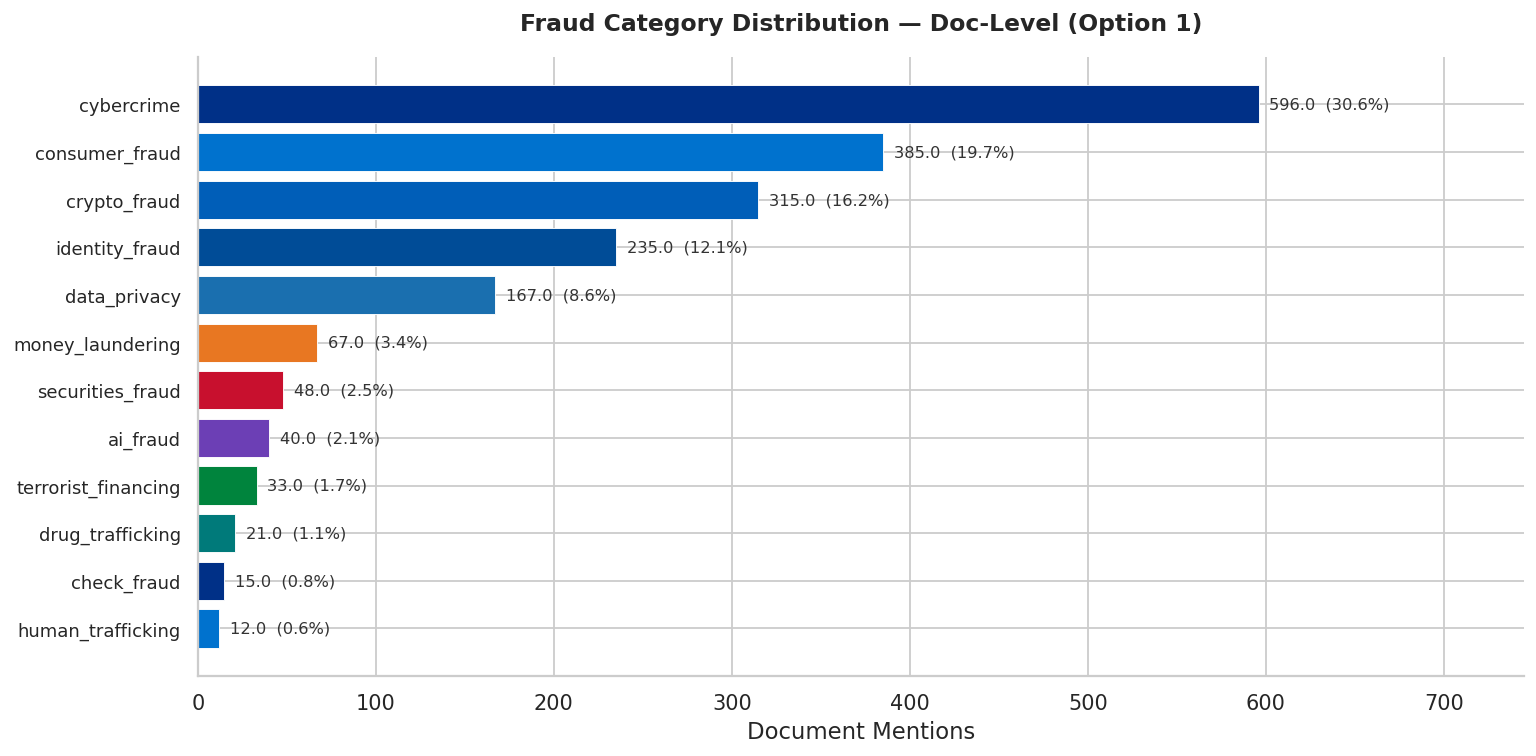

  Saved: 5a_trend_by_year_doc_level_(option_1).png


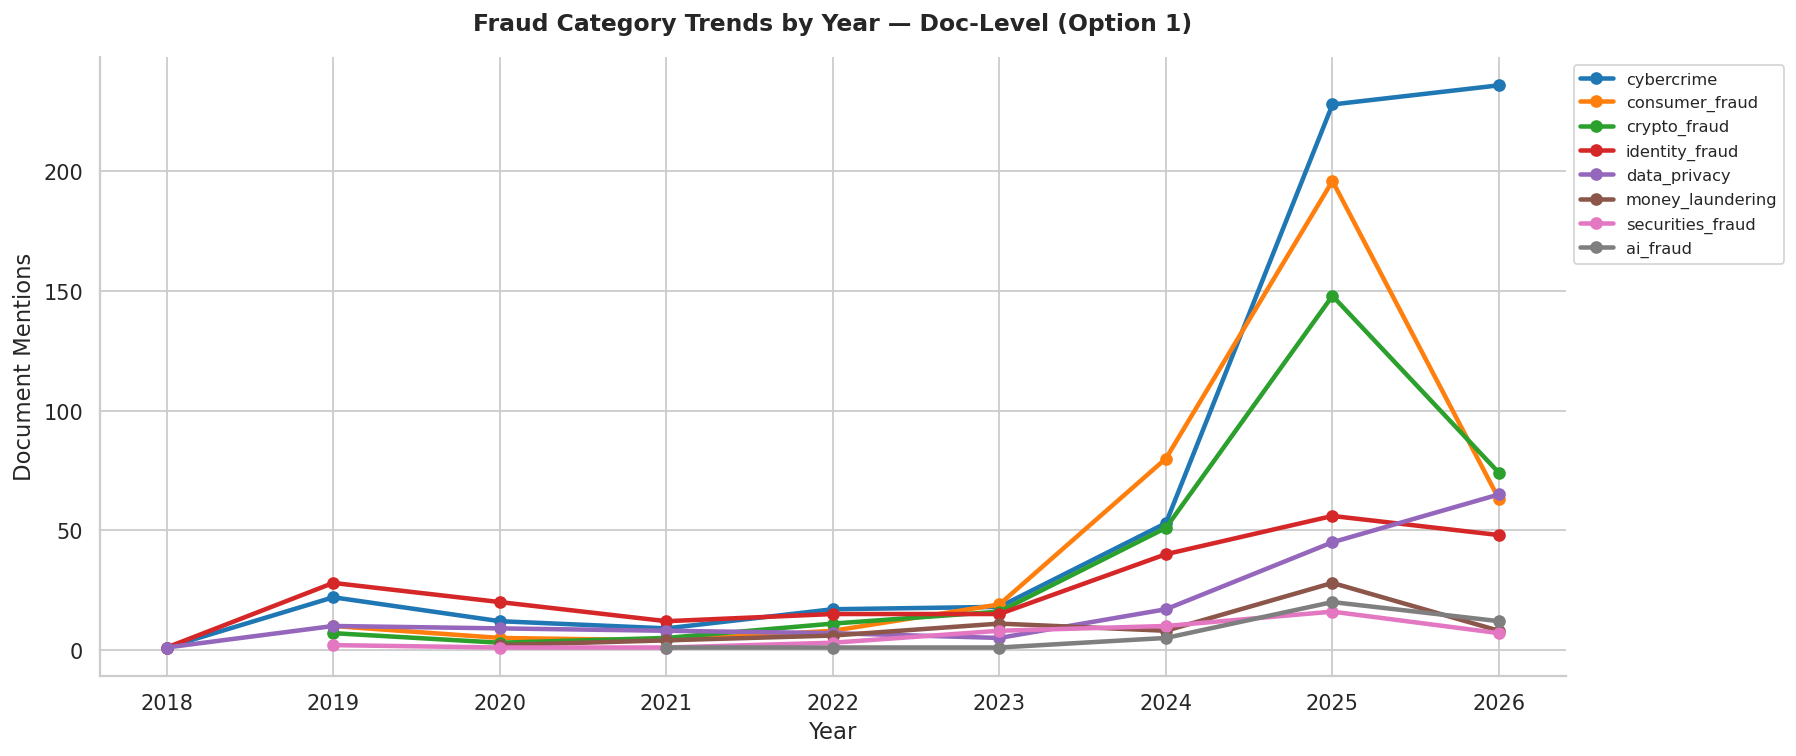

  Saved: 6_source_heatmap_doc_level_(option_1).png


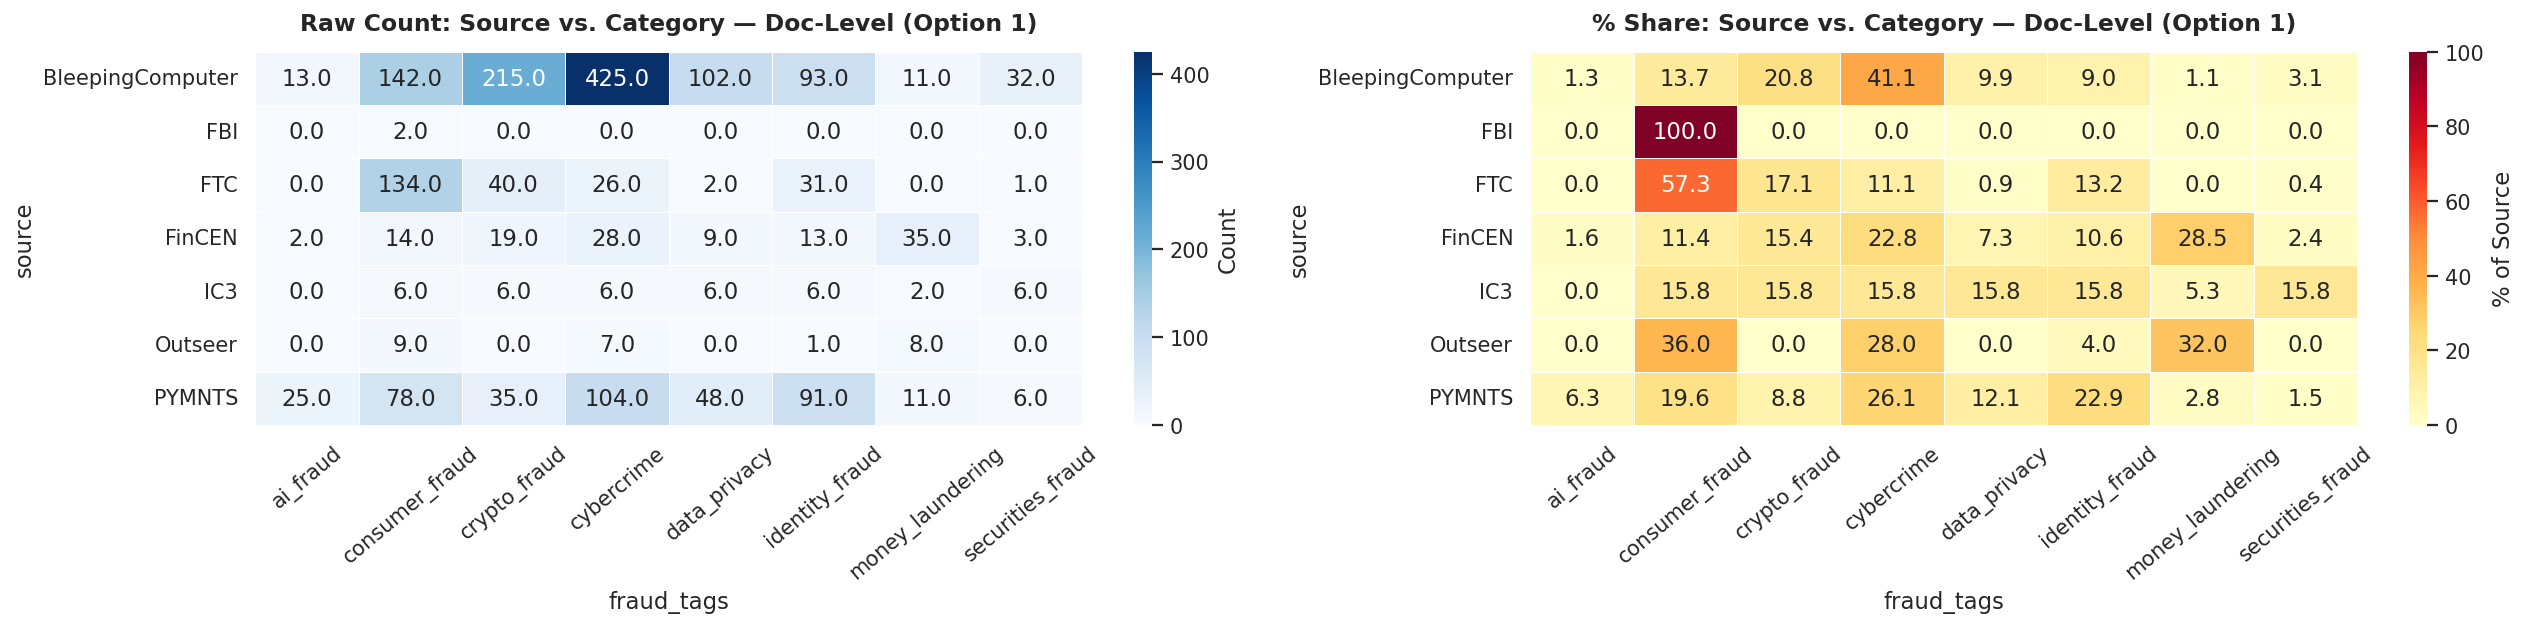

  Saved: 9_emerging_threats_doc_level_(option_1).png


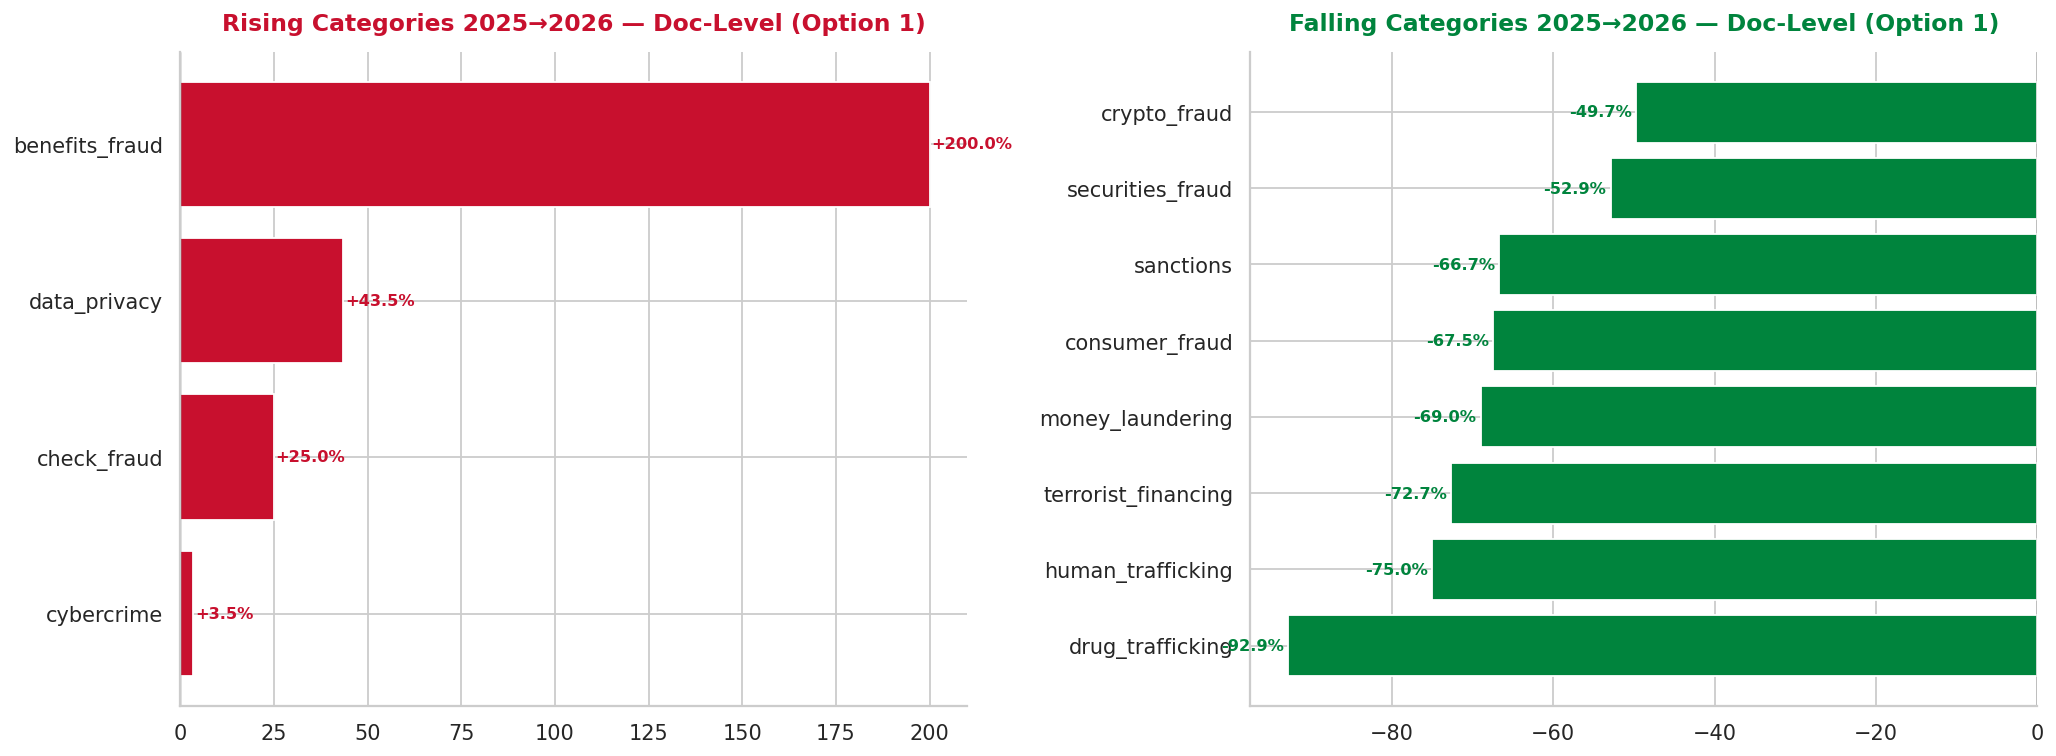


███████████████████████████████████████████████████████
  OPTION 2 — Weighted Chunks
  Chunk rows with weight = 1 / chunks_per_doc.
███████████████████████████████████████████████████████



  Weighted (Option 2) — Tag Distribution
                     count  pct%
fraud_tags                      
cybercrime           600.0  30.6
consumer_fraud       388.0  19.8
crypto_fraud         315.0  16.1
identity_fraud       235.0  12.0
data_privacy         167.0   8.5
money_laundering      70.0   3.6
securities_fraud      48.0   2.4
ai_fraud              40.0   2.0
terrorist_financing   33.0   1.7
drug_trafficking      21.0   1.1
check_fraud           15.0   0.8
human_trafficking     12.0   0.6
sanctions             11.0   0.6
benefits_fraud         5.0   0.3


  Saved: 4_category_distribution_weighted_(option_2).png


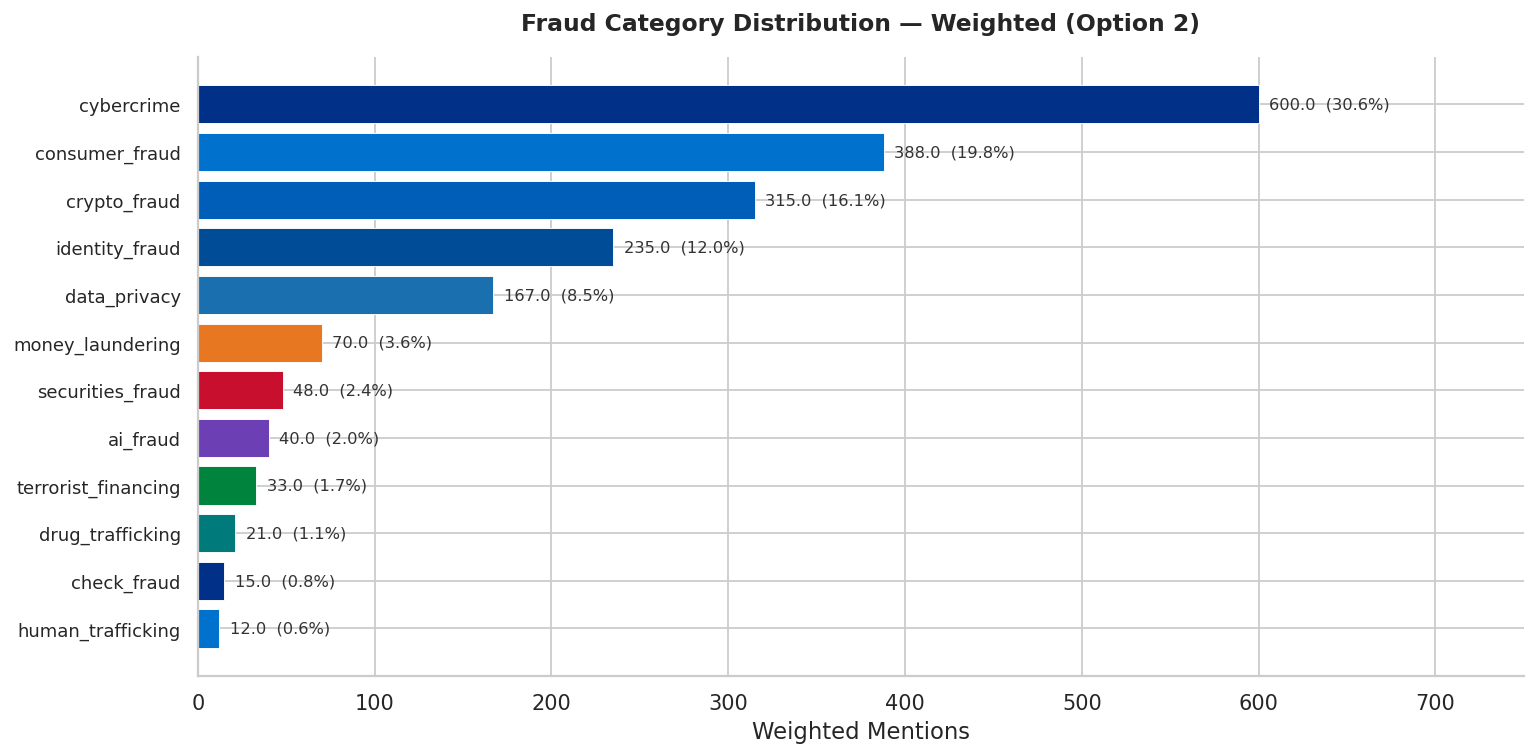

  Saved: 5a_trend_by_year_weighted_(option_2).png


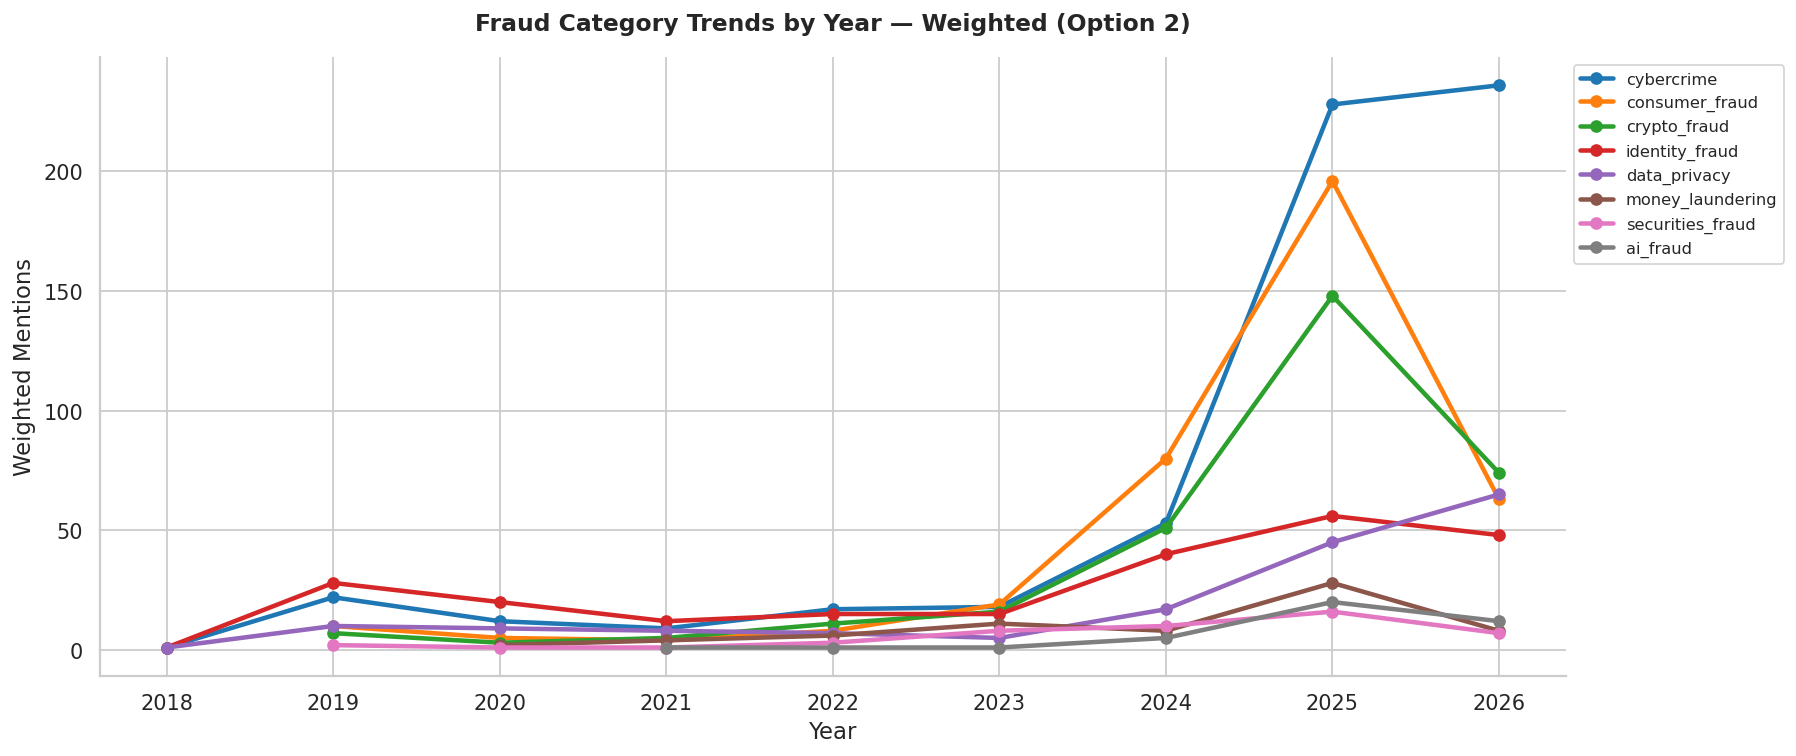

  Saved: 6_source_heatmap_weighted_(option_2).png


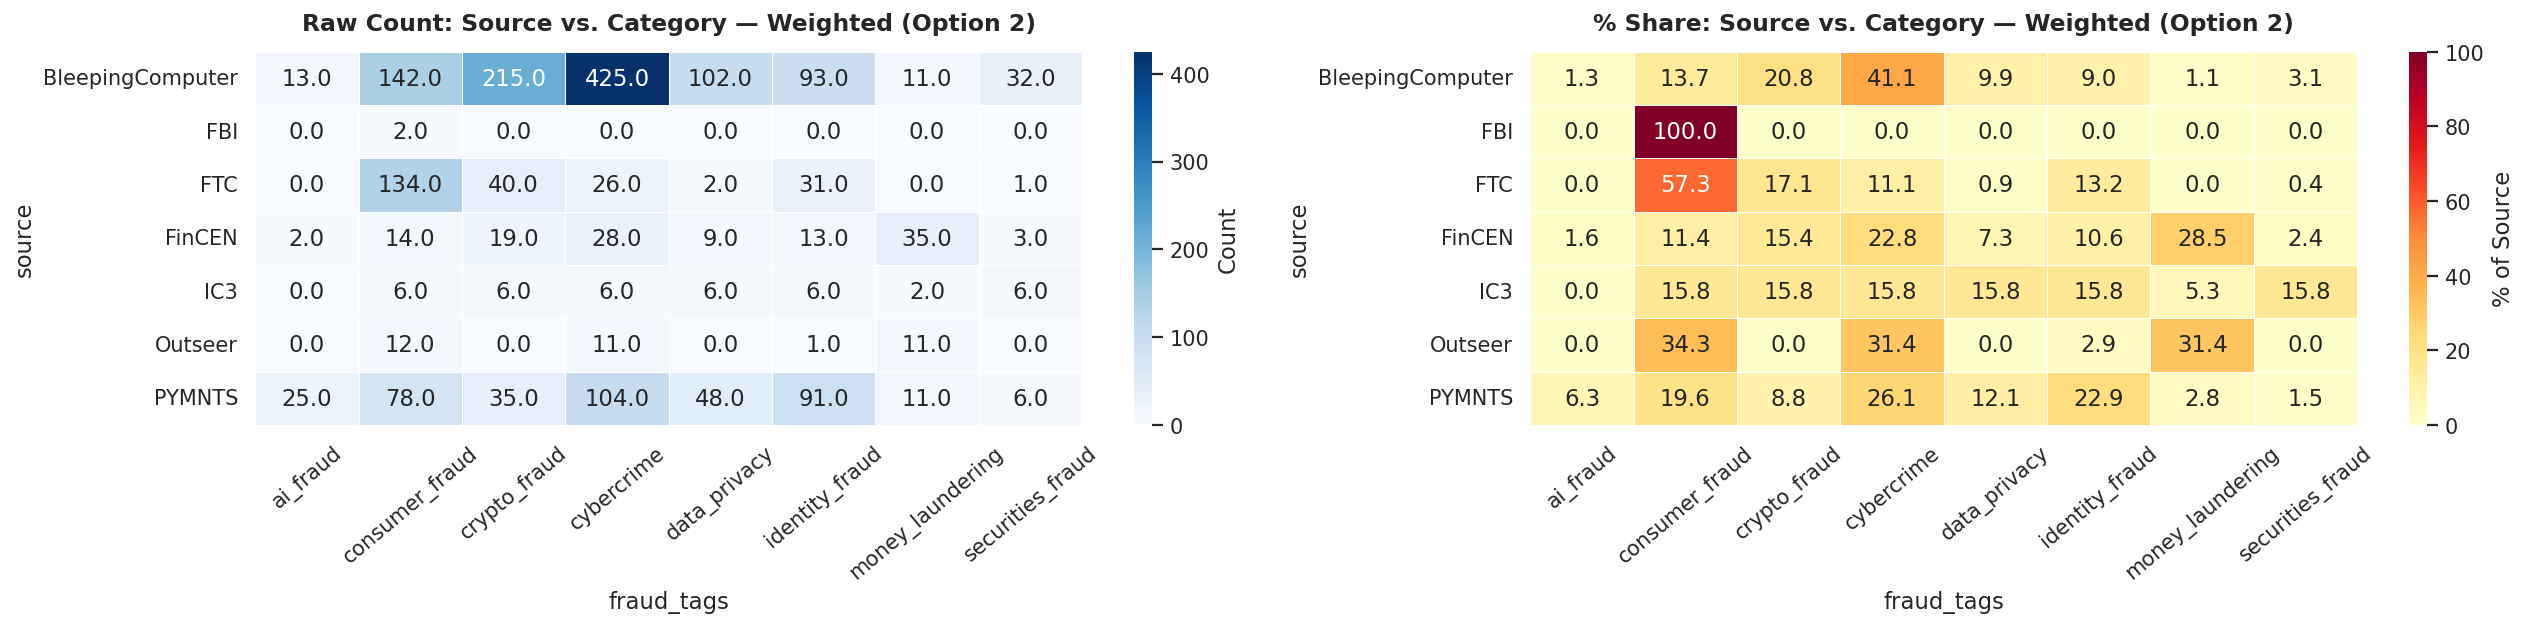

  Saved: 9_emerging_threats_weighted_(option_2).png


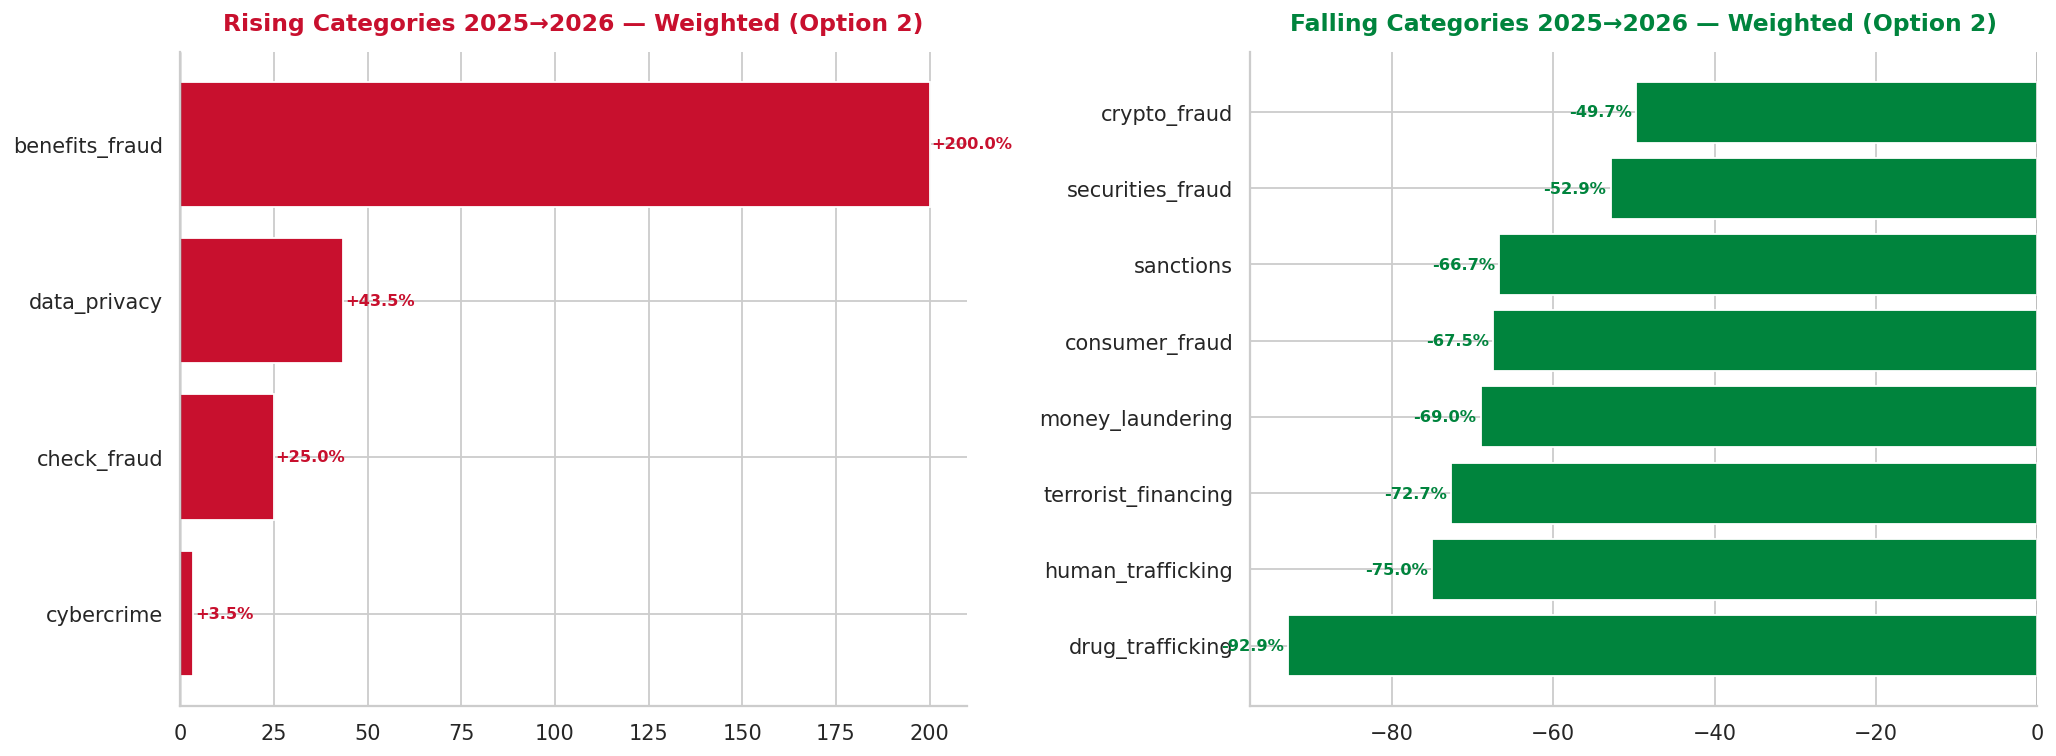

In [9]:
# ══════════════════════════════════════════════════════════════
# Run analysis for both views
# ══════════════════════════════════════════════════════════════

print('\n' + '█' * 55)
print('  OPTION 1 — Doc-Level (Union Merge)')
print('  One row per document. Equal weight per source.')
print('█' * 55)
tag_counts_docs, trend_docs, src_tag_docs, pivot_docs = run_analysis(
    master_docs, 'Doc-Level (Option 1)'
)

print('\n' + '█' * 55)
print('  OPTION 2 — Weighted Chunks')
print('  Chunk rows with weight = 1 / chunks_per_doc.')
print('█' * 55)
tag_counts_wtd, trend_wtd, src_tag_wtd, pivot_wtd = run_analysis(
    master_weighted, 'Weighted (Option 2)', weight_col='chunk_weight'
)


## Step 6 — Run Both Analysis Views

---
## Section 4 — Fraud Category Distribution
**Dashboard panel: Top fraud types bar chart**

Total fraud tag occurrences: 1960
Unique categories: 14
                     count  pct%
fraud_tags                      
cybercrime             600  30.6
consumer_fraud         388  19.8
crypto_fraud           315  16.1
identity_fraud         235  12.0
data_privacy           167   8.5
money_laundering        70   3.6
securities_fraud        48   2.4
ai_fraud                40   2.0
terrorist_financing     33   1.7
drug_trafficking        21   1.1
check_fraud             15   0.8
human_trafficking       12   0.6
sanctions               11   0.6
benefits_fraud           5   0.3


  Saved: 4_category_distribution.png


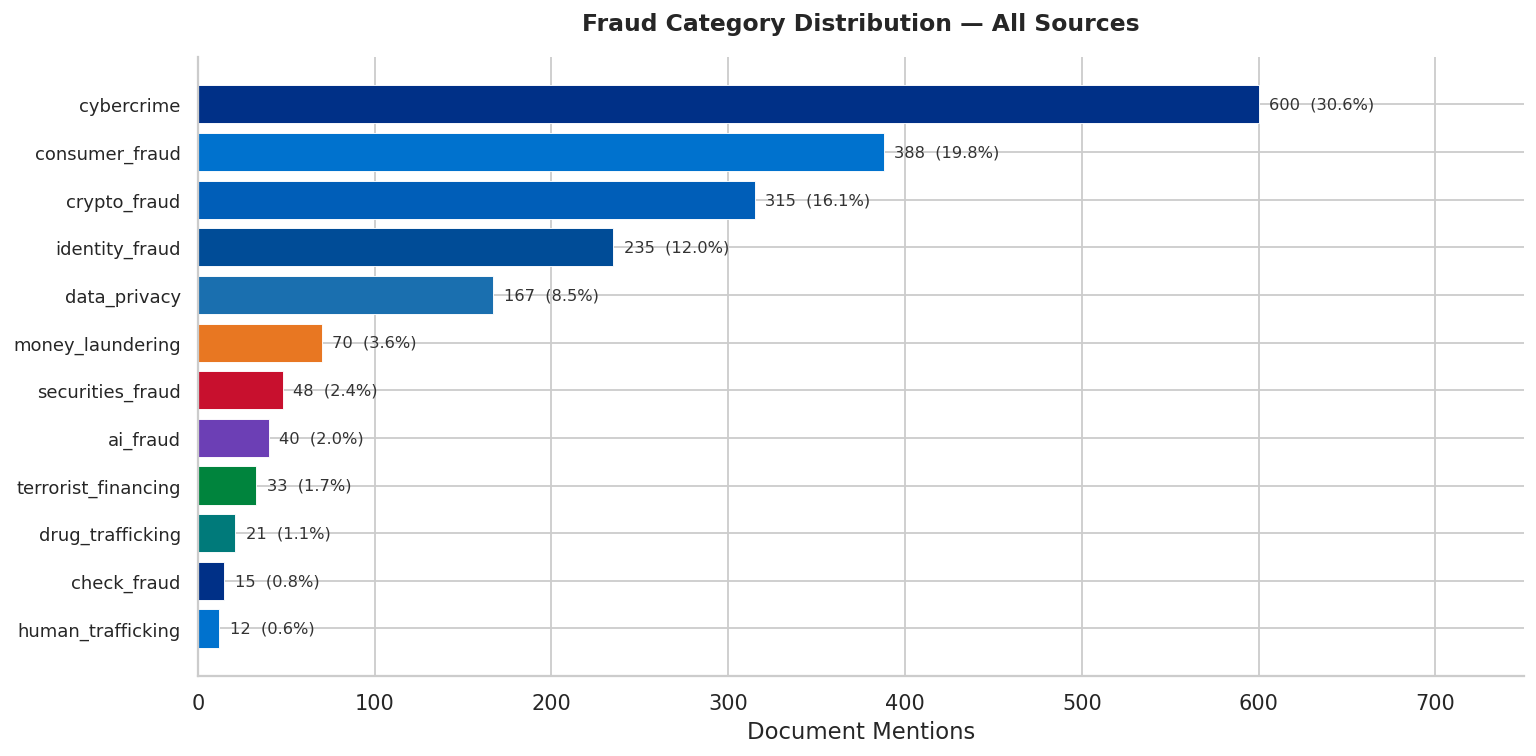

In [10]:
# ══════════════════════════════════════════════════════════════
# Section 4 — Fraud Category Distribution
# Dashboard panel: Top fraud types bar chart
# ══════════════════════════════════════════════════════════════

tags_exploded = master.explode('fraud_tags')
# After explode, ensure individual tag values are plain strings
tags_exploded['fraud_tags'] = tags_exploded['fraud_tags'].apply(
    lambda t: str(t).strip() if not isinstance(t, list) else (str(t[0]).strip() if t else '')
)
tags_exploded = tags_exploded[
    tags_exploded['fraud_tags'].notna() &
    (tags_exploded['fraud_tags'] != '') &
    (tags_exploded['fraud_tags'] != 'other')
]

tag_counts = tags_exploded['fraud_tags'].value_counts()
tag_pct    = (tag_counts / tag_counts.sum() * 100).round(1)

print('Total fraud tag occurrences:', tag_counts.sum())
print('Unique categories:', len(tag_counts))
print(pd.DataFrame({'count': tag_counts, 'pct%': tag_pct}).to_string())

# ── Chart
top_n = min(len(tag_counts), 12)
top_tags = tag_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [CATEGORY_COLORS[i % len(CATEGORY_COLORS)] for i in range(top_n)]
bars = ax.barh(
    top_tags.index[::-1], top_tags.values[::-1],
    color=colors[::-1], edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, top_tags.values[::-1]):
    pct = val / tag_counts.sum() * 100
    ax.text(bar.get_width() + tag_counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9, color='#333')

ax.set_title('Fraud Category Distribution — All Sources', pad=15)
ax.set_xlabel('Document Mentions')
ax.set_xlim(0, tag_counts.max() * 1.25)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
save_chart(fig, '4_category_distribution')
plt.show()


---
## Section 5 — Fraud Trends Over Time
**Dashboard panel: Fraud category line chart by year**

  Saved: 5a_trend_by_year.png


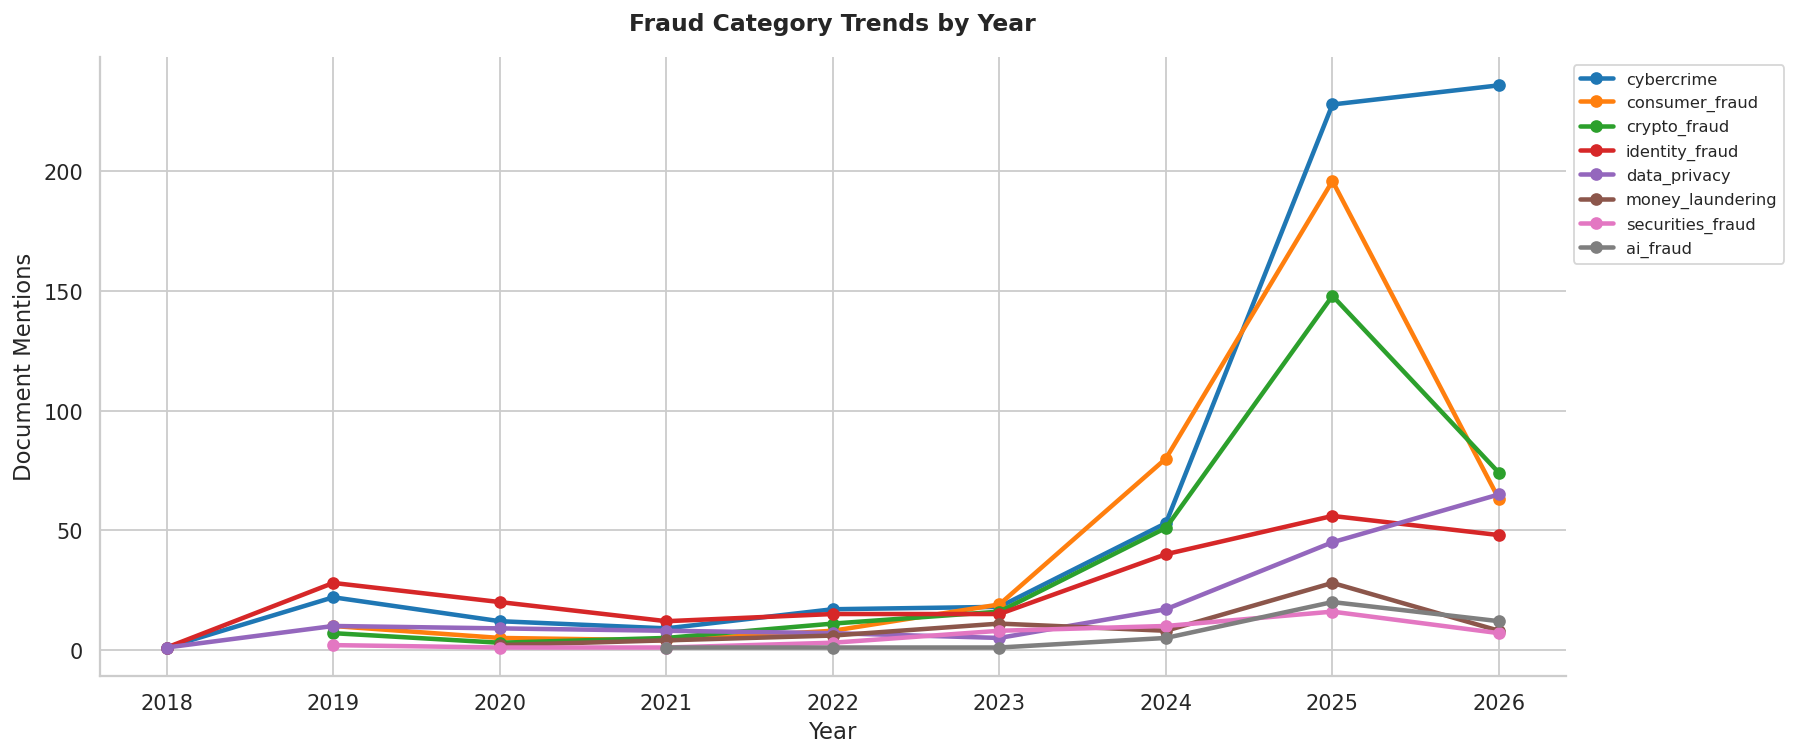

  Saved: 5b_quarterly_heatmap.png


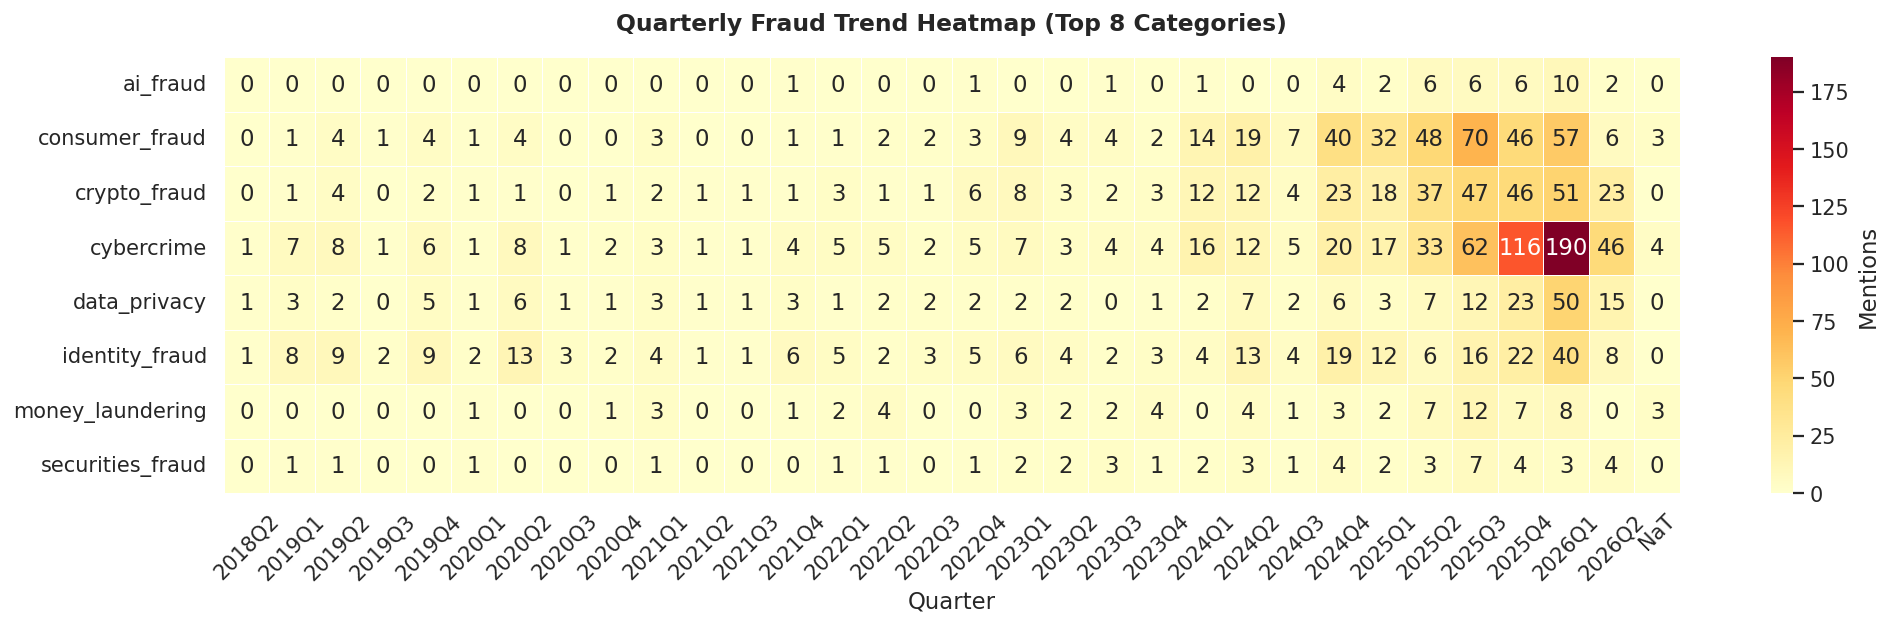

In [11]:
# ══════════════════════════════════════════════════════════════
# Section 5 — Fraud Trends Over Time
# Dashboard panel: Yearly + quarterly line charts
# ══════════════════════════════════════════════════════════════

top8_tags = tag_counts.head(8).index.tolist()

trend_df = (
    tags_exploded[tags_exploded['fraud_tags'].isin(top8_tags)]
    .groupby(['year', 'fraud_tags'])
    .size().reset_index(name='count')
    .dropna(subset=['year'])
)
trend_df['year'] = trend_df['year'].astype(int)

# ── Yearly line chart
fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', len(top8_tags))
for i, tag in enumerate(top8_tags):
    subset = trend_df[trend_df['fraud_tags'] == tag].sort_values('year')
    ax.plot(subset['year'], subset['count'], marker='o',
            label=tag, color=palette[i], linewidth=2.5, markersize=6)

ax.set_title('Fraud Category Trends by Year', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Document Mentions')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9, framealpha=0.8)
plt.tight_layout()
save_chart(fig, '5a_trend_by_year')
plt.show()

# ── Quarterly heatmap (more compact than line chart for many categories)
quarterly = (
    tags_exploded[tags_exploded['fraud_tags'].isin(top8_tags)]
    .groupby(['quarter', 'fraud_tags'])
    .size().reset_index(name='count')
    .dropna(subset=['quarter'])
    .sort_values('quarter')
)

pivot_q = quarterly.pivot(index='fraud_tags', columns='quarter', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_q, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Mentions'}
)
ax.set_title('Quarterly Fraud Trend Heatmap (Top 8 Categories)', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_chart(fig, '5b_quarterly_heatmap')
plt.show()


---
## Section 6 — Source Comparison
**Dashboard panel: Source vs. category heatmap**

Raw counts per source:
fraud_tags        ai_fraud  consumer_fraud  crypto_fraud  cybercrime  data_privacy  identity_fraud  money_laundering  securities_fraud
source                                                                                                                                
BleepingComputer      13.0           142.0         215.0       425.0         102.0            93.0              11.0              32.0
FBI                    0.0             2.0           0.0         0.0           0.0             0.0               0.0               0.0
FTC                    0.0           134.0          40.0        26.0           2.0            31.0               0.0               1.0
FinCEN                 2.0            14.0          19.0        28.0           9.0            13.0              35.0               3.0
IC3                    0.0             6.0           6.0         6.0           6.0             6.0               2.0               6.0
Outseer                0.0      

  Saved: 6a_source_heatmap.png


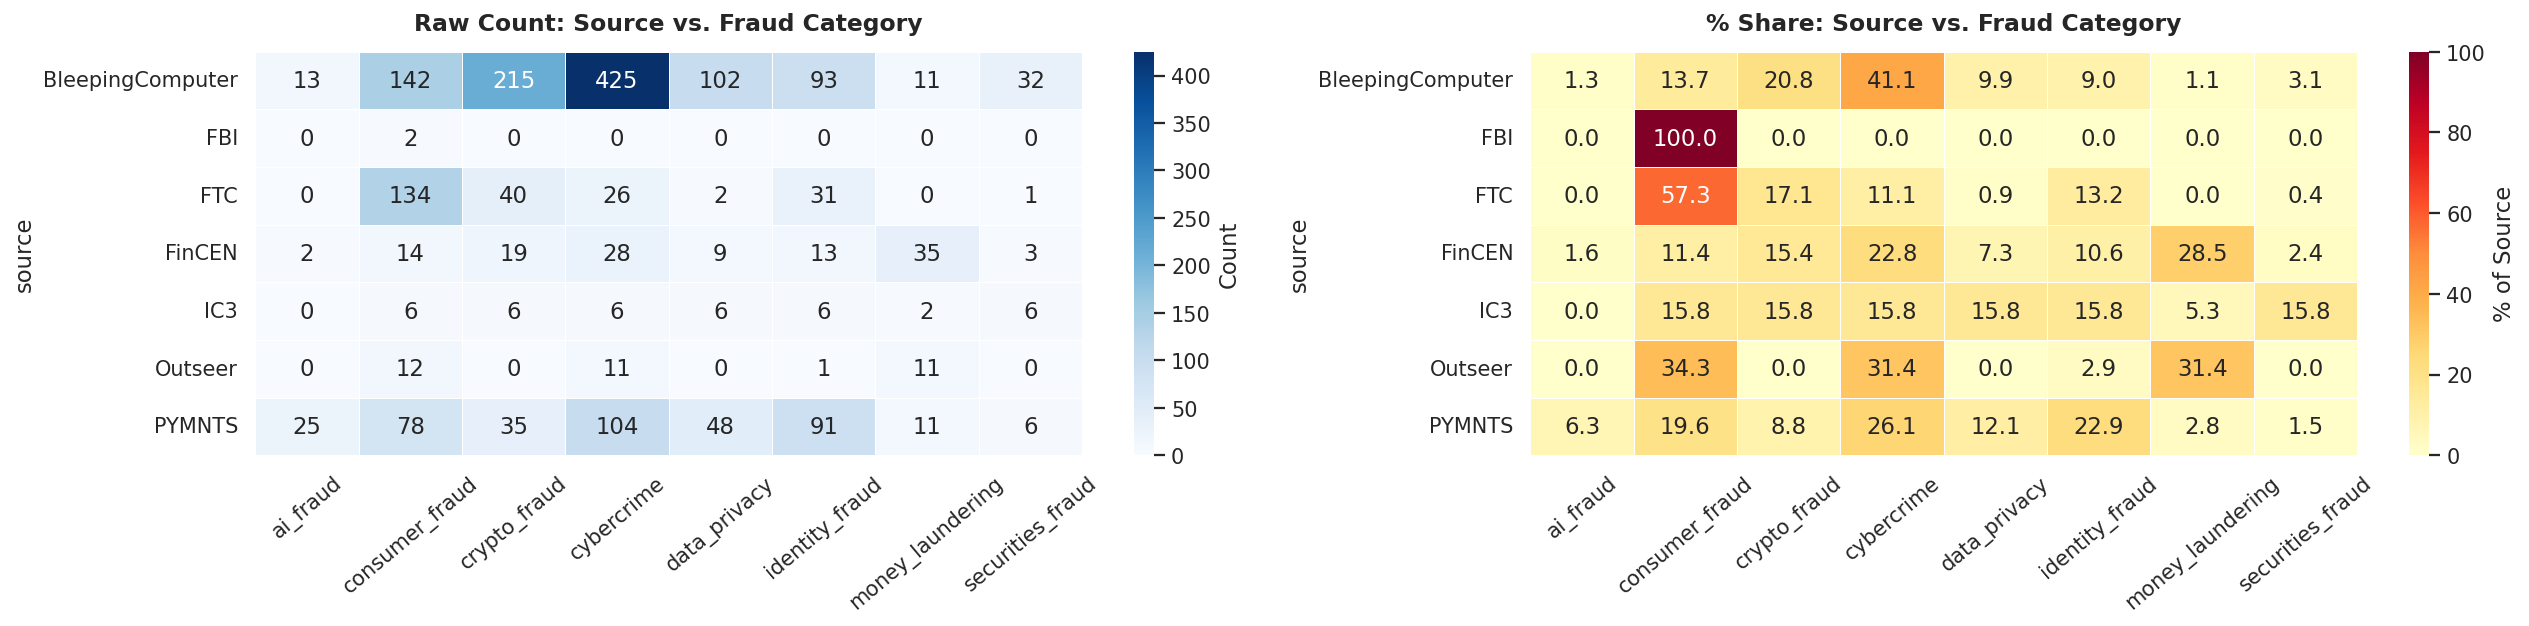

  Saved: 6b_source_stacked_bar.png


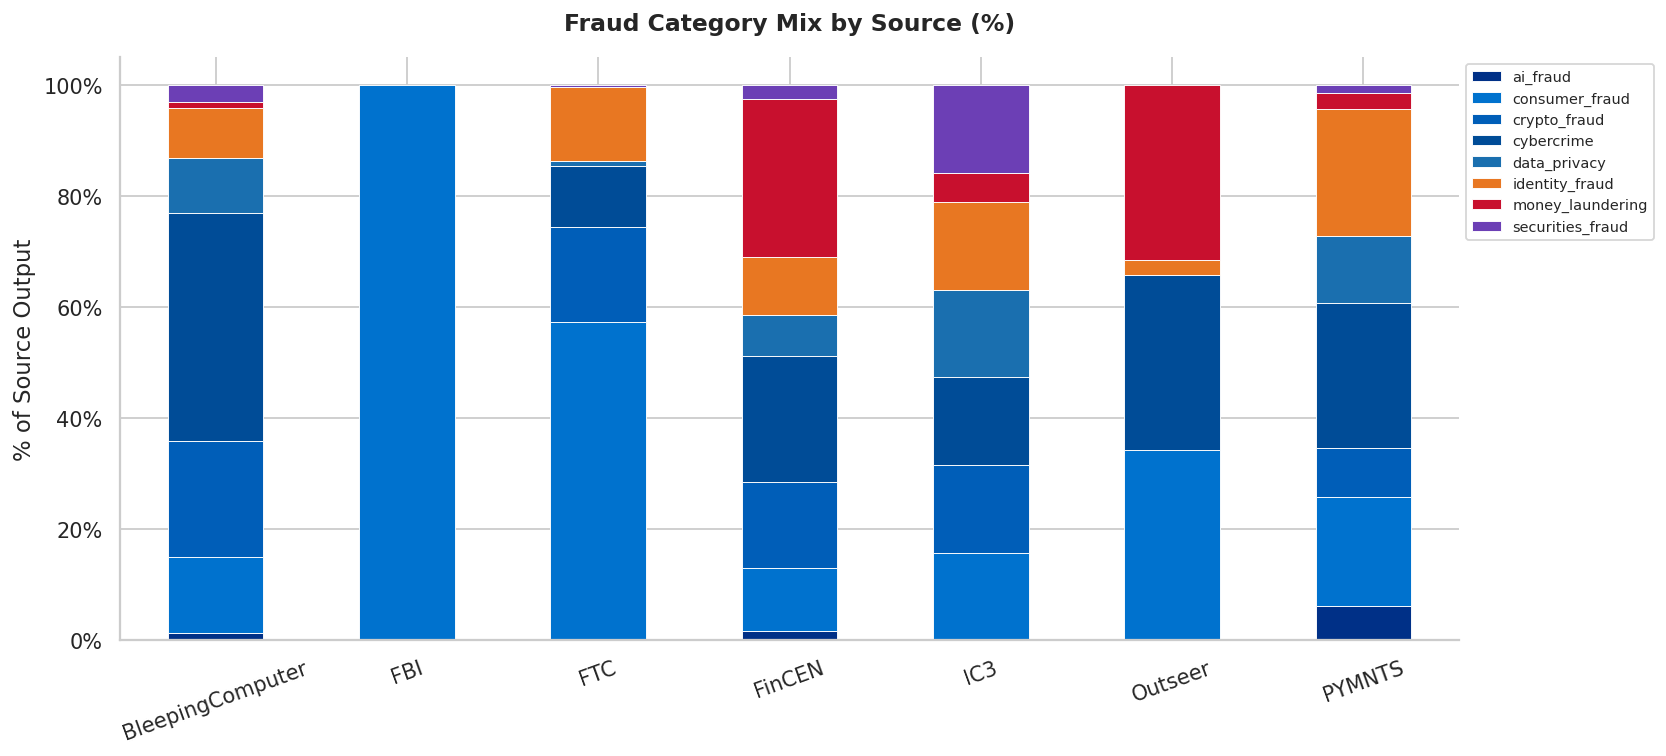

In [12]:
# ══════════════════════════════════════════════════════════════
# Section 6 — Source Comparison
# Dashboard panel: Source vs. category heatmap + stacked bar
# ══════════════════════════════════════════════════════════════

source_tag_df = (
    tags_exploded[tags_exploded['fraud_tags'].isin(top8_tags)]
    .groupby(['source', 'fraud_tags'])
    .size().reset_index(name='count')
)

pivot_src     = source_tag_df.pivot(index='source', columns='fraud_tags', values='count').fillna(0)
pivot_src_pct = pivot_src.div(pivot_src.sum(axis=1), axis=0) * 100

print('Raw counts per source:')
print(pivot_src.to_string())

# ── Side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.heatmap(pivot_src, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Raw Count: Source vs. Fraud Category', pad=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=40)

sns.heatmap(pivot_src_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=axes[1], cbar_kws={'label': '% of Source'})
axes[1].set_title('% Share: Source vs. Fraud Category', pad=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
save_chart(fig, '6a_source_heatmap')
plt.show()

# ── Stacked bar — source specialization
fig, ax = plt.subplots(figsize=(13, 6))
pivot_src_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=CATEGORY_COLORS[:len(pivot_src_pct.columns)],
    edgecolor='white', linewidth=0.5
)
ax.set_title('Fraud Category Mix by Source (%)', pad=15)
ax.set_ylabel('% of Source Output')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
save_chart(fig, '6b_source_stacked_bar')
plt.show()


---
## Section 7 — Fraud Signal Analysis
**Dashboard panel: Signal frequency scorecards**

Signal frequency:
        signal  count  pct
          URLs      0  0.0
        Emails      7  0.6
 Phone Numbers     16  1.3
  IP Addresses      0  0.0
Crypto Wallets      0  0.0


  Saved: 7_signal_analysis.png


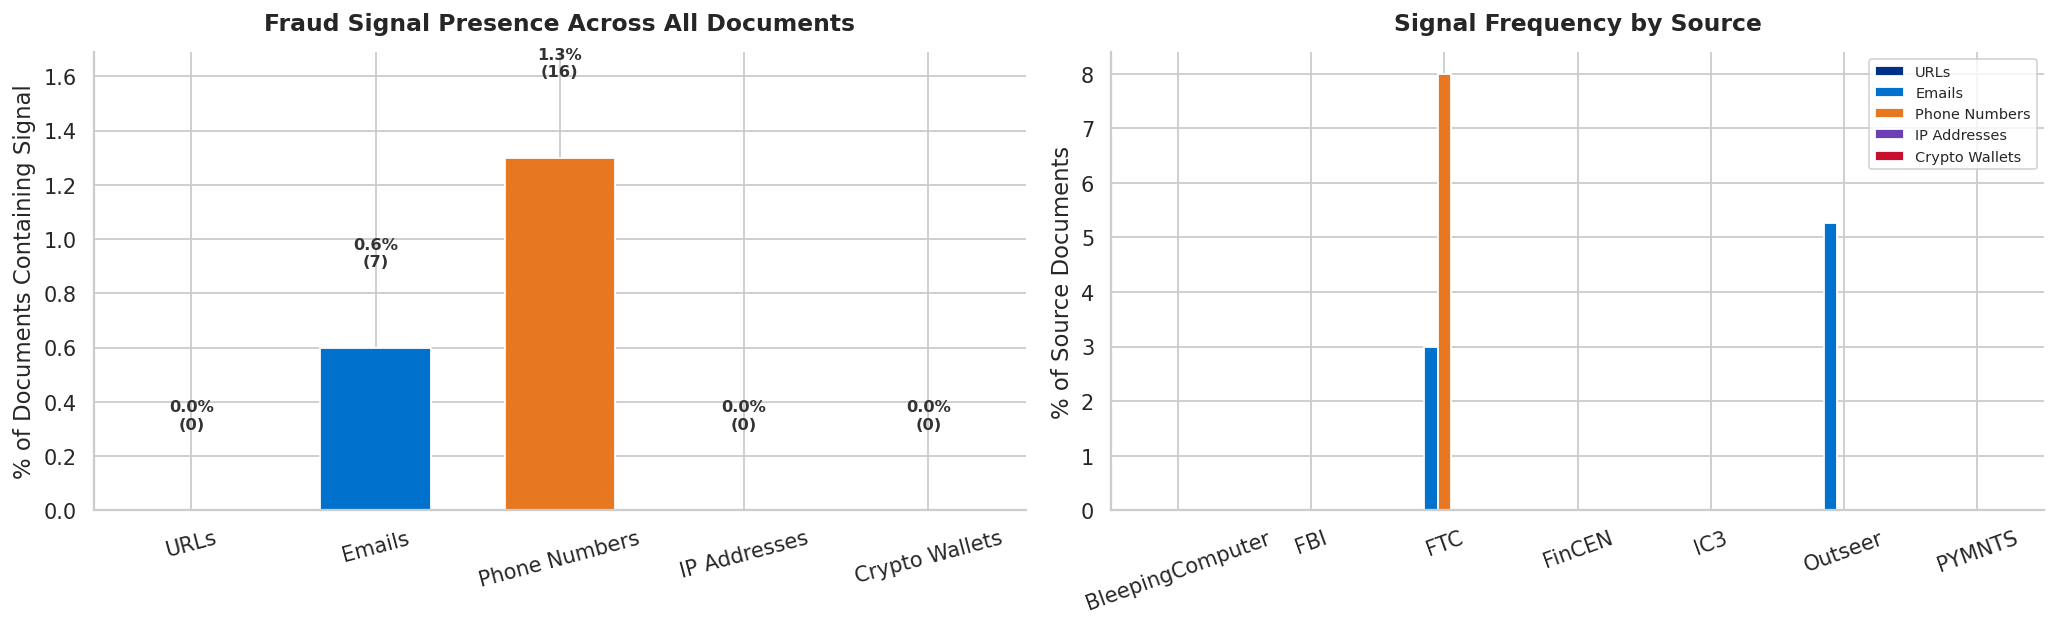

  Saved: 7b_signal_trend.png


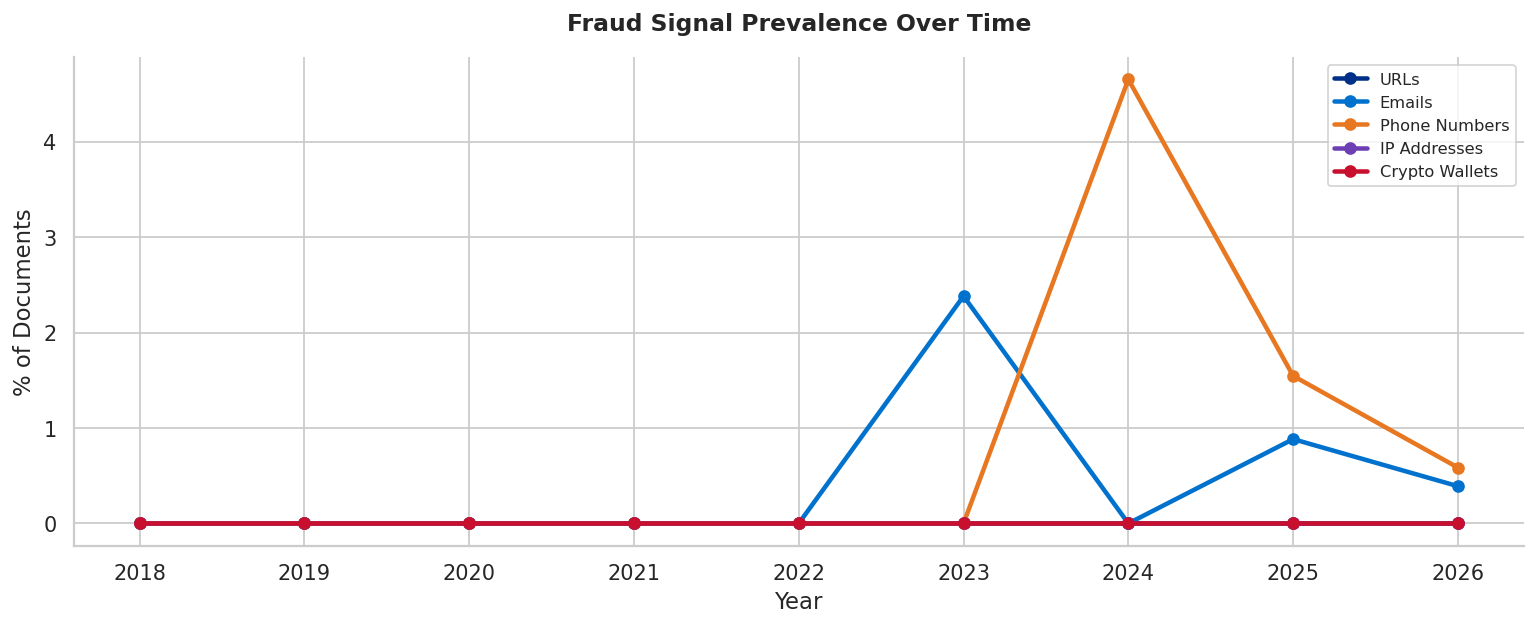

In [13]:
# ══════════════════════════════════════════════════════════════
# Section 7 — Fraud Signal Analysis
# Dashboard panel: Signal frequency scorecards + trend
# ══════════════════════════════════════════════════════════════

signal_cols   = ['has_url', 'has_email', 'has_phone', 'has_ip', 'has_crypto']
signal_labels = ['URLs', 'Emails', 'Phone Numbers', 'IP Addresses', 'Crypto Wallets']
signal_colors = ['#003087', '#0072CE', '#E87722', '#6C3FB5', '#C8102E']

signal_summary = pd.DataFrame({
    'signal': signal_labels,
    'count':  [master[c].sum() for c in signal_cols],
    'pct':    [(master[c].mean() * 100).round(1) for c in signal_cols]
})

print('Signal frequency:')
print(signal_summary.to_string(index=False))

# ── Scorecard-style bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(signal_summary['signal'], signal_summary['pct'],
                   color=signal_colors, edgecolor='white', width=0.6)
for bar, row in zip(bars, signal_summary.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{row.pct}%\n({int(row.count):,})',
                 ha='center', fontsize=9, fontweight='bold', color='#333')
axes[0].set_title('Fraud Signal Presence Across All Documents', pad=12)
axes[0].set_ylabel('% of Documents Containing Signal')
axes[0].set_ylim(0, signal_summary['pct'].max() * 1.3)
axes[0].tick_params(axis='x', rotation=15)

# ── Signal by source
signal_by_source = master.groupby('source')[signal_cols].mean() * 100
signal_by_source.columns = signal_labels
signal_by_source.plot(kind='bar', ax=axes[1], color=signal_colors, edgecolor='white')
axes[1].set_title('Signal Frequency by Source', pad=12)
axes[1].set_ylabel('% of Source Documents')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)

plt.tight_layout()
save_chart(fig, '7_signal_analysis')
plt.show()

# ── Signal trend over time
signal_trend = (
    master.dropna(subset=['year'])
    .groupby('year')[signal_cols].mean() * 100
)
signal_trend.columns = signal_labels
signal_trend.index = signal_trend.index.astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(signal_labels, signal_colors):
    ax.plot(signal_trend.index, signal_trend[col],
            marker='o', linewidth=2.5, markersize=6, label=col, color=color)
ax.set_title('Fraud Signal Prevalence Over Time', pad=15)
ax.set_ylabel('% of Documents')
ax.set_xlabel('Year')
ax.legend(bbox_to_anchor=(1, 1), fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
save_chart(fig, '7b_signal_trend')
plt.show()


---
## Section 8 — Signal Co-occurrence (Compound Fraud Patterns)
**Dashboard panel: Which signals appear together — compound fraud fingerprints**

  Saved: 8_signal_cooccurrence.png


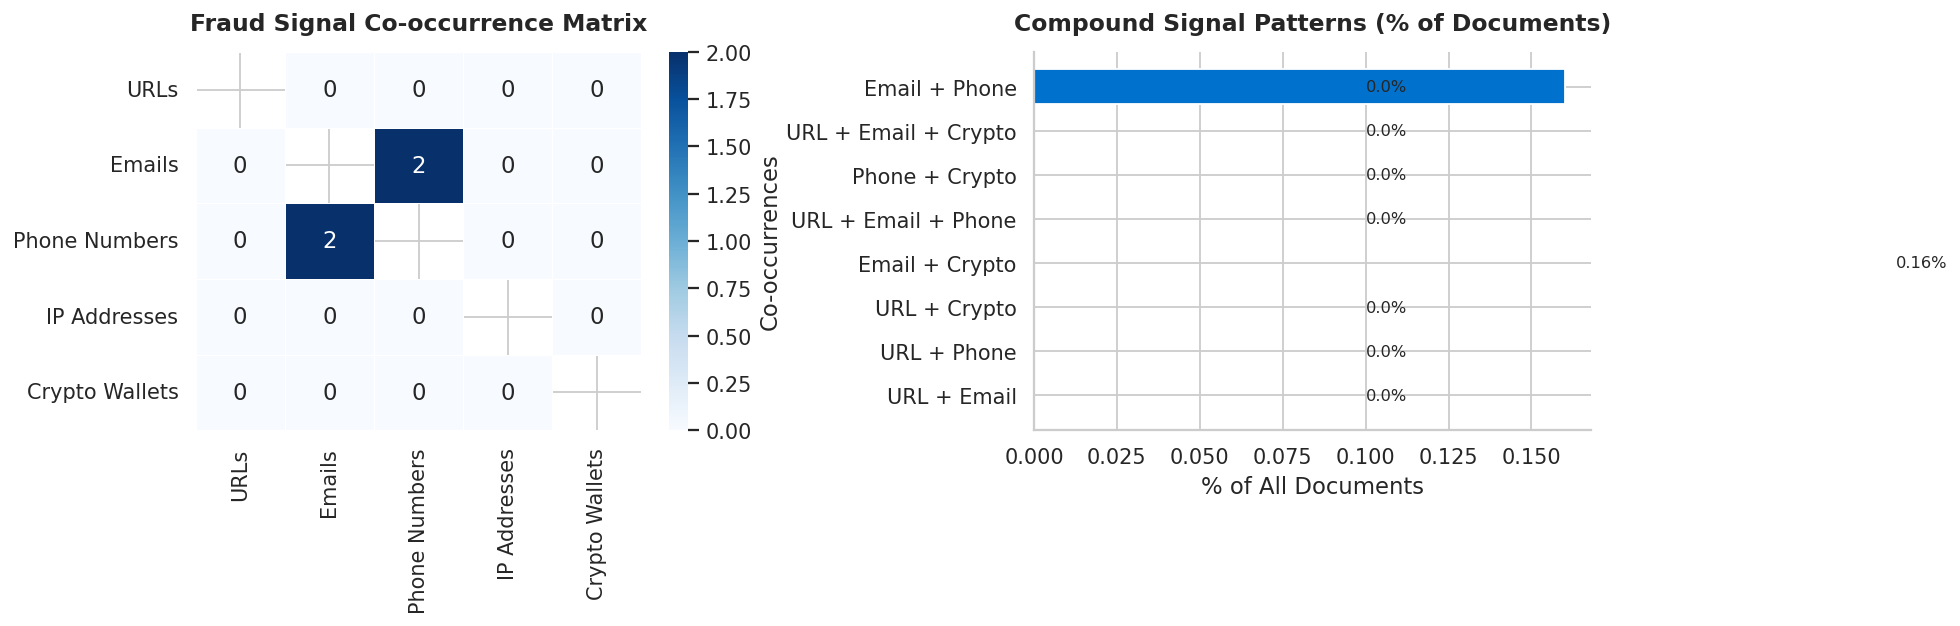

In [14]:
# ══════════════════════════════════════════════════════════════
# Section 8 — Signal Co-occurrence
# Dashboard panel: Compound fraud fingerprints
# ══════════════════════════════════════════════════════════════

signal_df = master[signal_cols].astype(int)
cooccur   = signal_df.T.dot(signal_df)
cooccur.index   = signal_labels
cooccur.columns = signal_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.eye(len(cooccur), dtype=bool)
sns.heatmap(cooccur, annot=True, fmt='.0f', cmap='Blues',
            mask=mask, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Co-occurrences'})
axes[0].set_title('Fraud Signal Co-occurrence Matrix', pad=12)

# Compound patterns
compound_patterns = [
    ('URL + Email',          master['has_url']   & master['has_email']),
    ('URL + Phone',          master['has_url']   & master['has_phone']),
    ('URL + Crypto',         master['has_url']   & master['has_crypto']),
    ('Email + Phone',        master['has_email'] & master['has_phone']),
    ('Email + Crypto',       master['has_email'] & master['has_crypto']),
    ('Phone + Crypto',       master['has_phone'] & master['has_crypto']),
    ('URL + Email + Phone',  master['has_url']   & master['has_email'] & master['has_phone']),
    ('URL + Email + Crypto', master['has_url']   & master['has_email'] & master['has_crypto']),
]
pattern_df = pd.DataFrame([
    {'pattern': n, 'count': m.sum(), 'pct': round(m.mean() * 100, 2)}
    for n, m in compound_patterns
]).sort_values('count', ascending=True)

axes[1].barh(pattern_df['pattern'], pattern_df['pct'],
             color=PALETTE_SECONDARY, edgecolor='white')
for i, row in pattern_df.iterrows():
    axes[1].text(row['pct'] + 0.1, i - pattern_df.index[0],
                 f"{row['pct']}%", va='center', fontsize=9)
axes[1].set_title('Compound Signal Patterns (% of Documents)', pad=12)
axes[1].set_xlabel('% of All Documents')

plt.tight_layout()
save_chart(fig, '8_signal_cooccurrence')
plt.show()


---
## Section 9 — Emerging Threats
**Dashboard panel: Rising / falling fraud category indicators**

Comparing 2026 vs 2025


  Saved: 9_emerging_threats.png


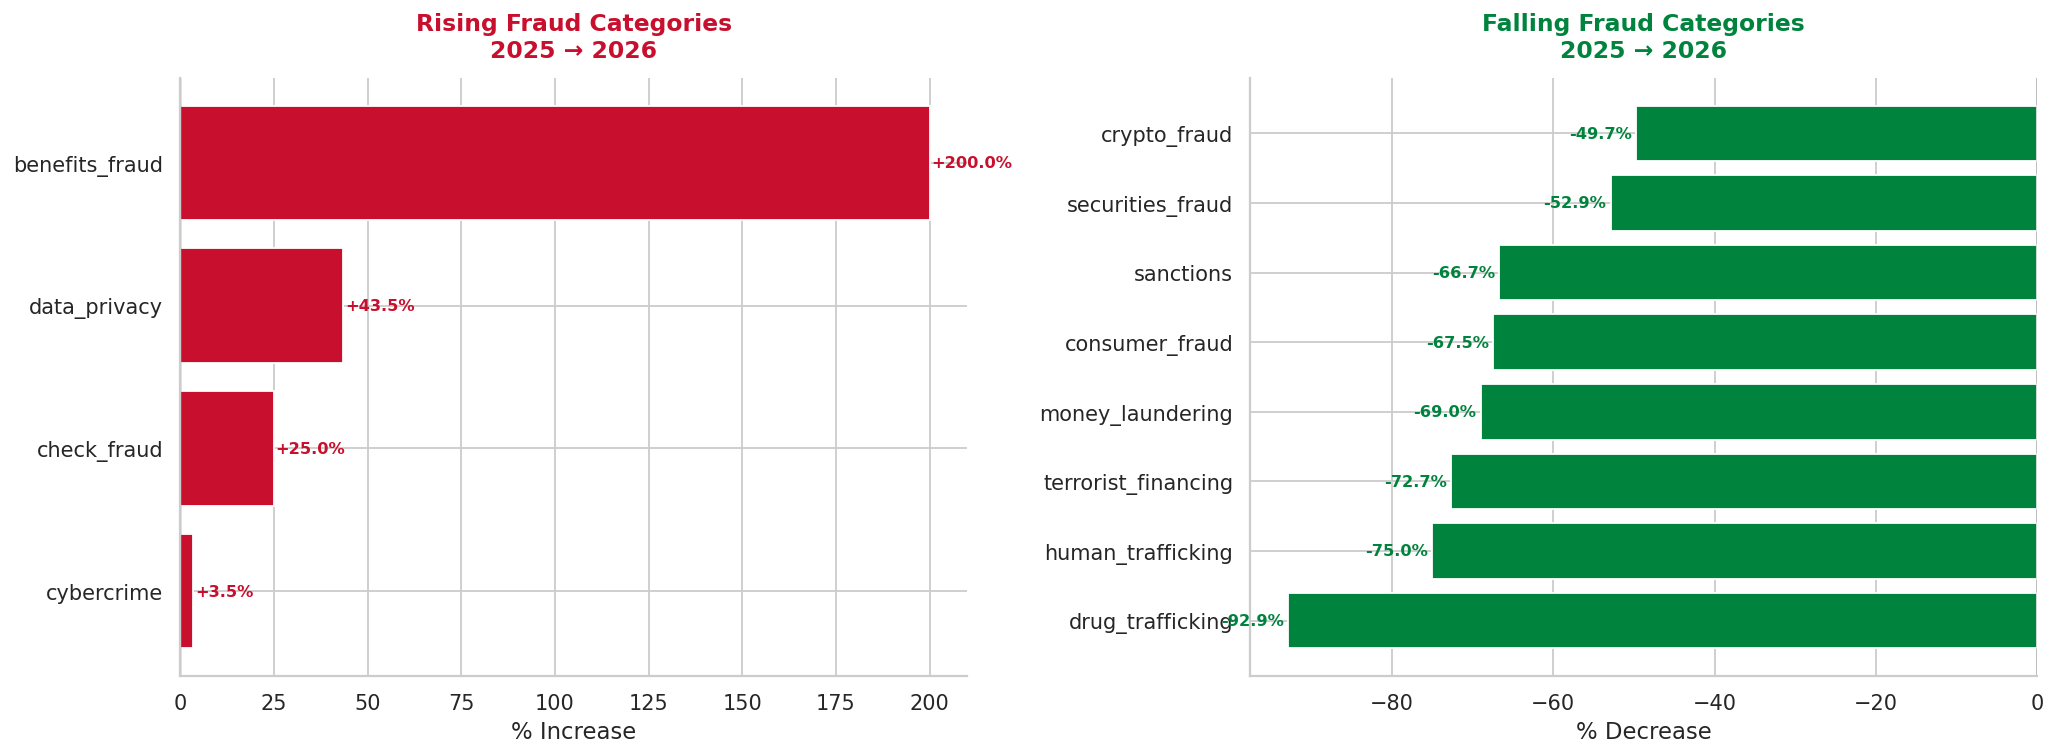


Fraud category YoY change:
                     2025_count  2026_count  change  pct_change
fraud_tags                                                     
benefits_fraud              0.0         2.0     2.0       200.0
data_privacy               45.0        65.0    20.0        43.5
check_fraud                 3.0         4.0     1.0        25.0
cybercrime                228.0       236.0     8.0         3.5
identity_fraud             56.0        48.0    -8.0       -14.0
ai_fraud                   20.0        12.0    -8.0       -38.1
crypto_fraud              148.0        74.0   -74.0       -49.7
securities_fraud           16.0         7.0    -9.0       -52.9
sanctions                   2.0         0.0    -2.0       -66.7
consumer_fraud            196.0        63.0  -133.0       -67.5
money_laundering           28.0         8.0   -20.0       -69.0
terrorist_financing        10.0         2.0    -8.0       -72.7
human_trafficking           7.0         1.0    -6.0       -75.0
drug_traffic

In [15]:
# ══════════════════════════════════════════════════════════════
# Section 9 — Emerging Threats
# Dashboard panel: Rising / falling category indicators
# ══════════════════════════════════════════════════════════════

recent_years = sorted(master['year'].dropna().unique())[-2:]

if len(recent_years) == 2:
    prev_year, curr_year = int(recent_years[0]), int(recent_years[1])
    print(f'Comparing {curr_year} vs {prev_year}')

    prev = tags_exploded[tags_exploded['year'] == prev_year]['fraud_tags'].value_counts()
    curr = tags_exploded[tags_exploded['year'] == curr_year]['fraud_tags'].value_counts()

    change_df = pd.DataFrame({'prev': prev, 'curr': curr}).fillna(0)
    change_df['change']     = change_df['curr'] - change_df['prev']
    change_df['pct_change'] = ((change_df['curr'] - change_df['prev']) / (change_df['prev'] + 1) * 100).round(1)
    change_df = change_df.sort_values('pct_change', ascending=False)
    change_df.columns = [f'{prev_year}_count', f'{curr_year}_count', 'change', 'pct_change']

    rising  = change_df[change_df['pct_change'] > 0].head(8)
    falling = change_df[change_df['pct_change'] < 0].tail(8)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Rising
    r_vals  = rising['pct_change'].values[::-1]
    r_labs  = rising.index[::-1]
    r_bars  = axes[0].barh(r_labs, r_vals, color=PALETTE_DANGER, edgecolor='white')
    for bar, val in zip(r_bars, r_vals):
        axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                     f'+{val:.1f}%', va='center', fontsize=9, color=PALETTE_DANGER, fontweight='bold')
    axes[0].set_title(f'Rising Fraud Categories\n{prev_year} → {curr_year}', pad=12, color=PALETTE_DANGER)
    axes[0].set_xlabel('% Increase')
    axes[0].axvline(0, color='gray', linewidth=0.8)

    # Falling
    f_vals  = falling['pct_change'].values[::-1]
    f_labs  = falling.index[::-1]
    f_bars  = axes[1].barh(f_labs, f_vals, color=PALETTE_SAFE, edgecolor='white')
    for bar, val in zip(f_bars, f_vals):
        axes[1].text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f}%', va='center', ha='right', fontsize=9,
                     color=PALETTE_SAFE, fontweight='bold')
    axes[1].set_title(f'Falling Fraud Categories\n{prev_year} → {curr_year}', pad=12, color=PALETTE_SAFE)
    axes[1].set_xlabel('% Decrease')
    axes[1].axvline(0, color='gray', linewidth=0.8)

    plt.tight_layout()
    save_chart(fig, '9_emerging_threats')
    plt.show()

    print(f'\nFraud category YoY change:')
    print(change_df.to_string())

    # New categories
    all_prev = set(tags_exploded[tags_exploded['year'] < curr_year]['fraud_tags'].unique())
    curr_set = set(tags_exploded[tags_exploded['year'] == curr_year]['fraud_tags'].unique())
    new_tags = curr_set - all_prev
    print(f'\nNew categories in {curr_year}:', sorted(new_tags) if new_tags else 'None')

else:
    print('Not enough year data for YoY comparison.')


---
## Section 10 — Export Dashboard-Ready CSVs

In [16]:
# ══════════════════════════════════════════════════════════════
# Export — save all views to dashboard_exports/
# ══════════════════════════════════════════════════════════════

EXPORT_DIR = os.path.join(DRIVE_FOLDER, 'dashboard_exports')
os.makedirs(EXPORT_DIR, exist_ok=True)

def export_view(tag_counts, trend_df, src_tag, suffix):
    """Export analytics CSVs for one view."""
    cat_dist = tag_counts.reset_index()
    cat_dist.columns = ['fraud_category', 'count']
    cat_dist['pct'] = (cat_dist['count'] / cat_dist['count'].sum() * 100).round(2)
    cat_dist.to_csv(os.path.join(EXPORT_DIR, f'category_distribution_{suffix}.csv'), index=False)
    trend_df.to_csv(os.path.join(EXPORT_DIR, f'trend_by_year_{suffix}.csv'), index=False)
    src_tag.to_csv(os.path.join(EXPORT_DIR, f'source_by_category_{suffix}.csv'), index=False)

# Option 1 exports
export_view(tag_counts_docs, trend_docs, src_tag_docs, 'docs')

# Option 2 exports
export_view(tag_counts_wtd, trend_wtd, src_tag_wtd, 'weighted')

# master_flat exports — all three versions
def save_master(df, fname, include_body=False):
    out = df.copy()

    # ── Serialize list columns ────────────────────────────────
    out['fraud_tags']    = out['fraud_tags'].apply(json.dumps)
    out['fraud_signals'] = out['fraud_signals'].apply(
        lambda x: json.dumps(x) if isinstance(x, (dict, list)) else (x or '{}')
    )

    # ── Drop stray level_1 if it snuck through ────────────────
    out.drop(columns=['level_1'], inplace=True, errors='ignore')

    # ── Identify body_N columns from wide-format sources ─────
    body_n_cols = sorted([c for c in out.columns if c.startswith('body_') and c.split('_')[1].isdigit()],
                         key=lambda c: int(c.split('_')[1]))

    # ── Handle body/text columns ─────────────────────────────
    if not include_body:
        drop_cols = [c for c in ['text', 'body'] if c in out.columns] + body_n_cols
        out.drop(columns=drop_cols, inplace=True)
    else:
        # Rename 'text' → 'body' if body not already present
        if 'body' not in out.columns and 'text' in out.columns:
            out.rename(columns={'text': 'body'}, inplace=True)
        elif 'text' in out.columns:
            out.drop(columns=['text'], inplace=True)

    # ── Column ordering: primary_tag, fraud_tags first ────────
    priority_cols = ['doc_id', 'source', 'date', 'year', 'month', 'quarter',
                     'primary_tag', 'fraud_tags']
    middle_cols   = [c for c in out.columns
                     if c not in priority_cols
                     and not c.startswith('body_')
                     and c != 'body']
    body_cols_final = ['body'] if 'body' in out.columns else []
    if include_body:
        body_cols_final += [c for c in body_n_cols if c in out.columns]

    ordered = [c for c in priority_cols if c in out.columns] +               [c for c in middle_cols   if c in out.columns] +               [c for c in body_cols_final if c in out.columns]
    # Any remaining columns not yet placed
    ordered += [c for c in out.columns if c not in ordered]
    out = out[ordered]

    out.to_csv(os.path.join(EXPORT_DIR, fname), index=False)
    size_kb = round(os.path.getsize(os.path.join(EXPORT_DIR, fname)) / 1024, 1)
    body_note = ' (includes body column)' if include_body else ''
    print(f'  {fname} ({len(out):,} rows, {size_kb} KB){body_note}')

print('Saving master files:')
save_master(master,          'master_flat.csv')                        # raw chunks
save_master(master_docs,     'master_flat_docs.csv', include_body=True) # doc-level + body_N
save_master(master_weighted, 'master_flat_weighted.csv')               # weighted chunks

# primary_tag distribution exports
pt_docs = master_docs['primary_tag'].value_counts().reset_index()
pt_docs.columns = ['primary_tag', 'count']
pt_docs['pct'] = (pt_docs['count'] / pt_docs['count'].sum() * 100).round(2)
pt_docs.to_csv(os.path.join(EXPORT_DIR, 'primary_tag_distribution_docs.csv'), index=False)

pt_wtd = master_weighted.groupby('primary_tag')['chunk_weight'].sum().sort_values(ascending=False).reset_index()
pt_wtd.columns = ['primary_tag', 'weighted_count']
pt_wtd['pct'] = (pt_wtd['weighted_count'] / pt_wtd['weighted_count'].sum() * 100).round(2)
pt_wtd.to_csv(os.path.join(EXPORT_DIR, 'primary_tag_distribution_weighted.csv'), index=False)

print('\nAll exports saved to:', EXPORT_DIR)
print('Files:')
for f in sorted(os.listdir(EXPORT_DIR)):
    size = round(os.path.getsize(os.path.join(EXPORT_DIR, f)) / 1024, 1)
    print(f'  {f} ({size} KB)')


Saving master files:
  master_flat.csv (1,237 rows, 250.1 KB)


  master_flat_docs.csv (1,231 rows, 9244.8 KB) (includes body column)
  master_flat_weighted.csv (1,237 rows, 250.1 KB)

All exports saved to: /content/drive/MyDrive/6390 UNCC Practicum - USAA/Fraud_model.v5/outputs/dashboard_exports
Files:
  OLD (4.0 KB)
  category_distribution_docs.csv (0.3 KB)
  category_distribution_weighted.csv (0.4 KB)
  charts (4.0 KB)
  master_flat.csv (250.1 KB)
  master_flat_docs.csv (9244.8 KB)
  master_flat_weighted.csv (250.1 KB)
  primary_tag_distribution_docs.csv (0.3 KB)
  primary_tag_distribution_weighted.csv (0.4 KB)
  source_by_category_docs.csv (1.0 KB)
  source_by_category_weighted.csv (1.1 KB)
  trend_by_year_docs.csv (1.4 KB)
  trend_by_year_weighted.csv (1.5 KB)


In [17]:
print(master.columns.tolist())

['text', 'fraud_tags', 'fraud_signals', 'date', 'source', 'doc_id', 'body_1', 'body_2', 'body_3', 'body_4', 'body_5', 'body_6', 'body_7', 'body_8', 'body_9', 'body_10', 'body_11', 'body_12', 'body_13', 'body_14', 'body_15', 'body_16', 'body_17', 'body_18', 'body_19', 'body_20', 'body_21', 'body_22', 'body_23', 'body_24', 'body_25', 'body_26', 'body_27', 'body_28', 'body_29', 'body_30', 'body_31', 'body_32', 'body_33', 'body_34', 'body_35', 'body_36', 'body_37', 'body_38', 'body_39', 'body_40', 'body_41', 'body_42', 'body_43', 'body_44', 'body_45', 'body_46', 'body_47', 'body_48', 'body_49', 'body_50', 'body_51', 'body_52', 'body_53', 'body_54', 'body_55', 'body_56', 'body_57', 'body_58', 'body_59', 'body_60', 'year', 'month', 'quarter', 'has_url', 'has_email', 'has_phone', 'has_ip', 'has_crypto', 'signal_count', 'text_length', 'tag_count', 'chunk_weight', 'primary_tag']


In [18]:
print('master_docs shape:', master_docs.shape)
print('master_docs source counts:')
print(master_docs['source'].value_counts())

master_docs shape: (1231, 78)
master_docs source counts:
source
BleepingComputer    550
PYMNTS              285
FTC                 200
FBI                 137
FinCEN               40
Outseer              13
IC3                   6
Name: count, dtype: int64


In [19]:
# Diagnostic — paste this as a new cell right after Cell 9
print('=== _scalar_agg ===')
print('Shape:', _scalar_agg.shape)
print('Cols:', _scalar_agg.columns.tolist())
print('doc_id sample:', _scalar_agg['doc_id'].head(3).tolist())
print()
print('=== _tags_agg ===')
print('Shape:', _tags_agg.shape)
print('Cols:', _tags_agg.columns.tolist())
print('Sample:')
print(_tags_agg.head(3).to_string())
print()
print('=== master doc_id ===')
print('dtype:', master['doc_id'].dtype)
print('NaN count:', master['doc_id'].isna().sum())
print('None count:', (master['doc_id'] == None).sum())
print('Sample:', master['doc_id'].head(6).tolist())
print('Unique:', master['doc_id'].nunique())

=== _scalar_agg ===
Shape: (1231, 12)
Cols: ['doc_id', 'source', 'date', 'year', 'month', 'quarter', 'text_length', 'has_url', 'has_email', 'has_phone', 'has_ip', 'has_crypto']
doc_id sample: ['0028265f7beb50', '00469c9548ac61', '0058b6fbe4505a']

=== _tags_agg ===
Shape: (1237, 2)
Cols: ['doc_id', 'fraud_tags']
Sample:
           doc_id                    fraud_tags
0  0028265f7beb50                       [other]
1  00469c9548ac61                       [other]
2  0058b6fbe4505a  [consumer_fraud, cybercrime]

=== master doc_id ===
dtype: object
NaN count: 0
None count: 0
Sample: ['FIN-2026-Alert001', 'FIN-2023-Alert001', 'FIN-2023-Alert002', 'FIN-2024-Alert001', 'FIN-2021-A001', 'FIN-2025-CTA1']
Unique: 1237


In [20]:
# Check row counts at each merge step
step1 = _scalar_agg.merge(_tags_agg, on='doc_id', how='left')
print('After merge with _tags_agg:', step1.shape)

step2 = step1.merge(_signals_agg, on='doc_id', how='left')
print('After merge with _signals_agg:', step2.shape)

# Check _signals_agg for duplicates
dup_sigs = _signals_agg[_signals_agg.duplicated('doc_id', keep=False)]
print()
print('Duplicate doc_ids in _signals_agg:', len(dup_sigs))
print('_signals_agg shape:', _signals_agg.shape)
print('_signals_agg columns:', _signals_agg.columns.tolist())
if len(dup_sigs) > 0:
    print(dup_sigs.head(5).to_string())

After merge with _tags_agg: (1231, 13)
After merge with _signals_agg: (1231, 14)

Duplicate doc_ids in _signals_agg: 0
_signals_agg shape: (1237, 2)
_signals_agg columns: ['doc_id', 'fraud_signals']


In [21]:
# Check what union_signals actually returns
sample_doc = master['doc_id'].iloc[0]
sample_signals = master[master['doc_id']==sample_doc]['fraud_signals'].tolist()
print('Raw signals for one doc:', sample_signals[:2])
print()
result = union_signals(pd.Series(sample_signals))
print('union_signals output type:', type(result))
print('union_signals output:', result)

Raw signals for one doc: [{}]

union_signals output type: <class 'dict'>
union_signals output: {}


In [22]:
# Replace _signals_agg construction — avoid apply() on dicts entirely
# Instead, keep fraud_signals as a list and pick first non-empty per doc
# (since signals are already unioned in the wide-format pipeline output,
#  there's only 1 row per doc in master, so just take the first value)
_signals_agg = (
    master
    .drop_duplicates(subset=['doc_id'], keep='first')[['doc_id', 'fraud_signals']]
    .copy()
    .reset_index(drop=True)
)
print('_signals_agg shape:', _signals_agg.shape)
print('Duplicate doc_ids:', _signals_agg['doc_id'].duplicated().sum())

_signals_agg shape: (1237, 2)
Duplicate doc_ids: 0


In [23]:
master_docs = (
    _scalar_agg
    .merge(_tags_agg,    on='doc_id', how='left')
    .merge(_signals_agg, on='doc_id', how='left')
)
print('master_docs shape:', master_docs.shape)
print('Source counts:')
print(master_docs['source'].value_counts())

master_docs shape: (1231, 14)
Source counts:
source
BleepingComputer    550
PYMNTS              285
FTC                 200
FBI                 137
FinCEN               40
Outseer              13
IC3                   6
Name: count, dtype: int64
